In [1]:
# ============================================
# FORECASTING - STEP 1
# LOAD M5 DATASETS
# ============================================

import pandas as pd
import numpy as np
import os

# Project root is one level above notebook/
project_root = ".."

# Raw data folder
raw_path = os.path.join(project_root, "Data", "Raw")

# File paths
sales_path = os.path.join(
    raw_path,
    "sales_train_validation.csv"
)

calendar_path = os.path.join(
    raw_path,
    "calendar.csv"
)

prices_path = os.path.join(
    raw_path,
    "sell_prices.csv"
)

# Load datasets
sales_df = pd.read_csv(sales_path)
calendar_df = pd.read_csv(calendar_path)
prices_df = pd.read_csv(prices_path)

print("=" * 60)
print("M5 DATASETS LOADED SUCCESSFULLY")
print("=" * 60)

print("\nSales Dataset:")
print("Rows   :", sales_df.shape[0])
print("Columns:", sales_df.shape[1])

print("\nCalendar Dataset:")
print("Rows   :", calendar_df.shape[0])
print("Columns:", calendar_df.shape[1])

print("\nPrice Dataset:")
print("Rows   :", prices_df.shape[0])
print("Columns:", prices_df.shape[1])

M5 DATASETS LOADED SUCCESSFULLY

Sales Dataset:
Rows   : 30490
Columns: 1918

Calendar Dataset:
Rows   : 1969
Columns: 13

Price Dataset:
Rows   : 6841121
Columns: 4


In [2]:
# ============================================
# FORECASTING - STEP 2
# CHECK FORECASTING DIMENSIONS
# ============================================

print("=" * 60)
print("FORECASTING DIMENSIONS")
print("=" * 60)

print("\nNumber of unique items:")
print(sales_df["item_id"].nunique())

print("\nNumber of unique stores:")
print(sales_df["store_id"].nunique())

print("\nNumber of unique categories:")
print(sales_df["cat_id"].nunique())

print("\nStores:")
print(sorted(sales_df["store_id"].unique()))

print("\nCategories:")
print(sorted(sales_df["cat_id"].unique()))

FORECASTING DIMENSIONS

Number of unique items:
3049

Number of unique stores:
10

Number of unique categories:
3

Stores:
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']

Categories:
['FOODS', 'HOBBIES', 'HOUSEHOLD']


In [3]:
# ============================================
# FORECASTING - STEP 3
# CREATE DAILY STORE-CATEGORY DATASET
# ============================================

# Identify daily sales columns
daily_columns = [
    col for col in sales_df.columns
    if col.startswith("d_")
]

print("Number of daily columns:", len(daily_columns))

# Aggregate item-level sales by store and category
store_category_sales = (
    sales_df
    .groupby(["store_id", "cat_id"])[daily_columns]
    .sum()
)

print("\nAggregated store-category data shape:")
print(store_category_sales.shape)

# Convert wide format to long format
forecast_df = store_category_sales.reset_index().melt(
    id_vars=["store_id", "cat_id"],
    value_vars=daily_columns,
    var_name="d",
    value_name="daily_sales"
)

print("\nLong-format forecasting data:")
print(forecast_df.shape)

# Connect d_1, d_2... with actual dates
day_mapping = calendar_df[["wm_yr_wk", "date"]].copy()

# Create sequential day mapping from calendar
day_mapping["d"] = [
    f"d_{i+1}" for i in range(len(day_mapping))
]

forecast_df = forecast_df.merge(
    day_mapping[["d", "date"]],
    on="d",
    how="left"
)

# Convert date to datetime
forecast_df["date"] = pd.to_datetime(forecast_df["date"])

# Sort the dataset
forecast_df = forecast_df.sort_values(
    ["store_id", "cat_id", "date"]
).reset_index(drop=True)

print("\n" + "=" * 60)
print("FORECASTING DATASET CREATED")
print("=" * 60)

print("\nRows   :", forecast_df.shape[0])
print("Columns:", forecast_df.shape[1])

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nFirst 10 rows:")
display(forecast_df.head(10))

Number of daily columns: 1913

Aggregated store-category data shape:
(30, 1913)


C:\Users\SAHITYA\AppData\Local\Temp\ipykernel_39560\2728865190.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  forecast_df = store_category_sales.reset_index().melt(



Long-format forecasting data:
(57390, 4)

FORECASTING DATASET CREATED

Rows   : 57390
Columns: 5

Columns:
['store_id', 'cat_id', 'd', 'daily_sales', 'date']

First 10 rows:


,store_id,cat_id,d,daily_sales,date
0,CA_1,FOODS,d_1,3239,2011-01-29
1,CA_1,FOODS,d_2,3137,2011-01-30
2,CA_1,FOODS,d_3,2008,2011-01-31
3,CA_1,FOODS,d_4,2258,2011-02-01
4,CA_1,FOODS,d_5,2032,2011-02-02
5,CA_1,FOODS,d_6,2407,2011-02-03
6,CA_1,FOODS,d_7,2693,2011-02-04
7,CA_1,FOODS,d_8,3962,2011-02-05
8,CA_1,FOODS,d_9,3418,2011-02-06
9,CA_1,FOODS,d_10,2446,2011-02-07


In [4]:
# ============================================
# FORECASTING - STEP 4
# CREATE TIME FEATURES
# ============================================

forecast_df["year"] = forecast_df["date"].dt.year
forecast_df["month"] = forecast_df["date"].dt.month
forecast_df["week"] = forecast_df["date"].dt.isocalendar().week.astype(int)
forecast_df["day_of_week"] = forecast_df["date"].dt.dayofweek
forecast_df["day_of_month"] = forecast_df["date"].dt.day

# Weekend indicator
forecast_df["is_weekend"] = (
    forecast_df["day_of_week"] >= 5
).astype(int)

print("=" * 60)
print("TIME FEATURES CREATED")
print("=" * 60)

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nSample:")
display(
    forecast_df[
        [
            "date",
            "store_id",
            "cat_id",
            "daily_sales",
            "year",
            "month",
            "week",
            "day_of_week",
            "day_of_month",
            "is_weekend"
        ]
    ].head(10)
)

TIME FEATURES CREATED

Columns:
['store_id', 'cat_id', 'd', 'daily_sales', 'date', 'year', 'month', 'week', 'day_of_week', 'day_of_month', 'is_weekend']

Sample:


,date,store_id,cat_id,daily_sales,year,month,week,day_of_week,day_of_month,is_weekend
0,2011-01-29,CA_1,FOODS,3239,2011,1,4,5,29,1
1,2011-01-30,CA_1,FOODS,3137,2011,1,4,6,30,1
2,2011-01-31,CA_1,FOODS,2008,2011,1,5,0,31,0
3,2011-02-01,CA_1,FOODS,2258,2011,2,5,1,1,0
4,2011-02-02,CA_1,FOODS,2032,2011,2,5,2,2,0
5,2011-02-03,CA_1,FOODS,2407,2011,2,5,3,3,0
6,2011-02-04,CA_1,FOODS,2693,2011,2,5,4,4,0
7,2011-02-05,CA_1,FOODS,3962,2011,2,5,5,5,1
8,2011-02-06,CA_1,FOODS,3418,2011,2,5,6,6,1
9,2011-02-07,CA_1,FOODS,2446,2011,2,6,0,7,0


In [5]:
# ============================================
# STEP 1: OVERALL TIME-SERIES ANALYSIS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Make sure date is in datetime format
forecast_df["date"] = pd.to_datetime(forecast_df["date"])

# Aggregate sales across all stores and categories
overall_daily_sales = (
    forecast_df
    .groupby("date")["daily_sales"]
    .sum()
    .reset_index()
)

print("OVERALL TIME-SERIES DATA")
print("=" * 60)

print("Number of dates:", len(overall_daily_sales))
print("Start date:", overall_daily_sales["date"].min().date())
print("End date:", overall_daily_sales["date"].max().date())

print("\nFirst 10 rows:")
print(overall_daily_sales.head(10))


OVERALL TIME-SERIES DATA
Number of dates: 1913
Start date: 2011-01-29
End date: 2016-04-24

First 10 rows:
        date  daily_sales
0 2011-01-29        32631
1 2011-01-30        31749
2 2011-01-31        23783
3 2011-02-01        25412
4 2011-02-02        19146
5 2011-02-03        29211
6 2011-02-04        28010
7 2011-02-05        37932
8 2011-02-06        32736
9 2011-02-07        25572


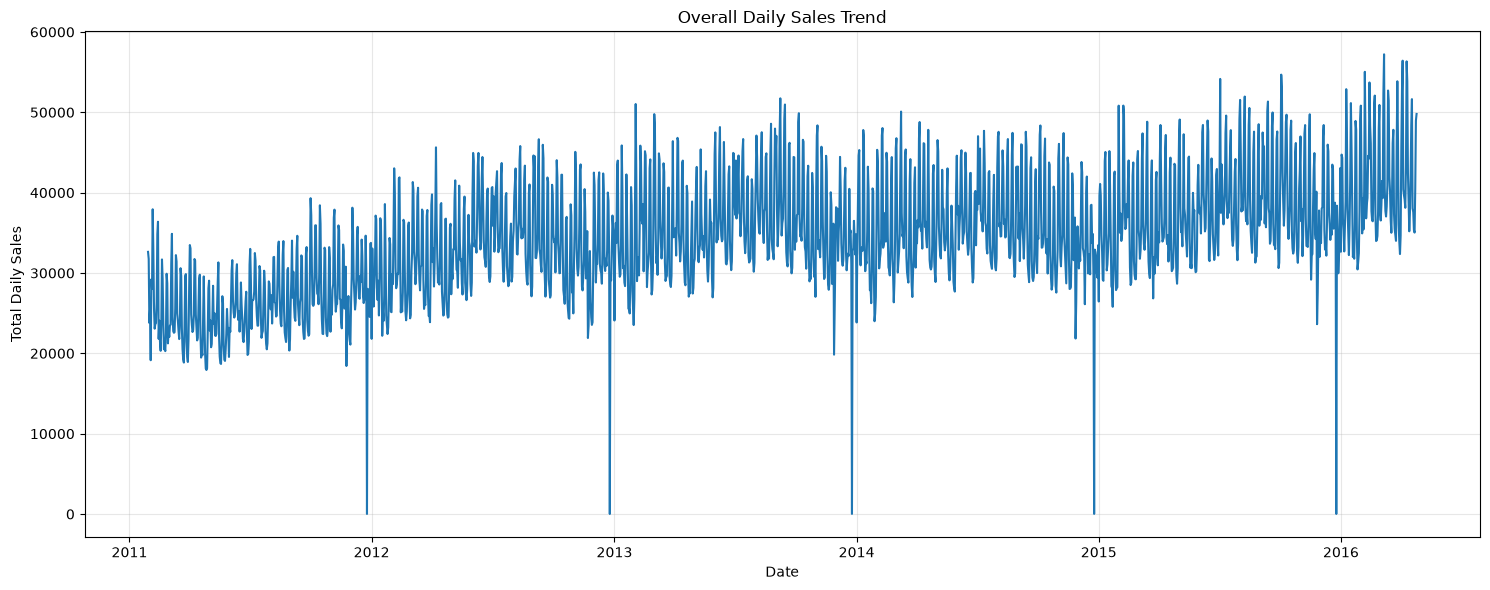

In [6]:

# --------------------------------------------
# Plot overall daily sales
# --------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    overall_daily_sales["date"],
    overall_daily_sales["daily_sales"]
)

plt.title("Overall Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Daily Sales")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# ============================================
# STEP 2: MONTHLY SALES SEASONALITY
# ============================================

# Make sure date is in datetime format
forecast_df["date"] = pd.to_datetime(forecast_df["date"])

# Calculate total sales for each date
sales_trend = (
    forecast_df
    .groupby("date")["daily_sales"]
    .sum()
    .reset_index()
)

# Add year and month
sales_trend["year"] = sales_trend["date"].dt.year
sales_trend["month"] = sales_trend["date"].dt.month

# Calculate monthly total sales
monthly_sales = (
    sales_trend
    .groupby(["year", "month"])["daily_sales"]
    .sum()
    .reset_index()
    .rename(columns={"daily_sales": "sales"})
)

print("MONTHLY SALES")
print("=" * 60)
print(monthly_sales.head(15))

# Average sales for each calendar month
average_sales_by_month = (
    monthly_sales
    .groupby("month")["sales"]
    .mean()
)

print("\nAVERAGE SALES BY MONTH")
print("=" * 60)
print(average_sales_by_month)

MONTHLY SALES
    year  month   sales
0   2011      1   88163
1   2011      2  726375
2   2011      3  763567
3   2011      4  737713
4   2011      5  719562
5   2011      6  753380
6   2011      7  819820
7   2011      8  825694
8   2011      9  813683
9   2011     10  898243
10  2011     11  823087
11  2011     12  887298
12  2012      1  893375
13  2012      2  897990
14  2012      3  986894

AVERAGE SALES BY MONTH
month
1     8.909185e+05
2     9.815982e+05
3     1.064535e+06
4     9.935018e+05
5     1.007619e+06
6     1.050042e+06
7     1.088795e+06
8     1.114346e+06
9     1.064378e+06
10    1.076118e+06
11    9.987248e+05
12    1.022394e+06
Name: sales, dtype: float64


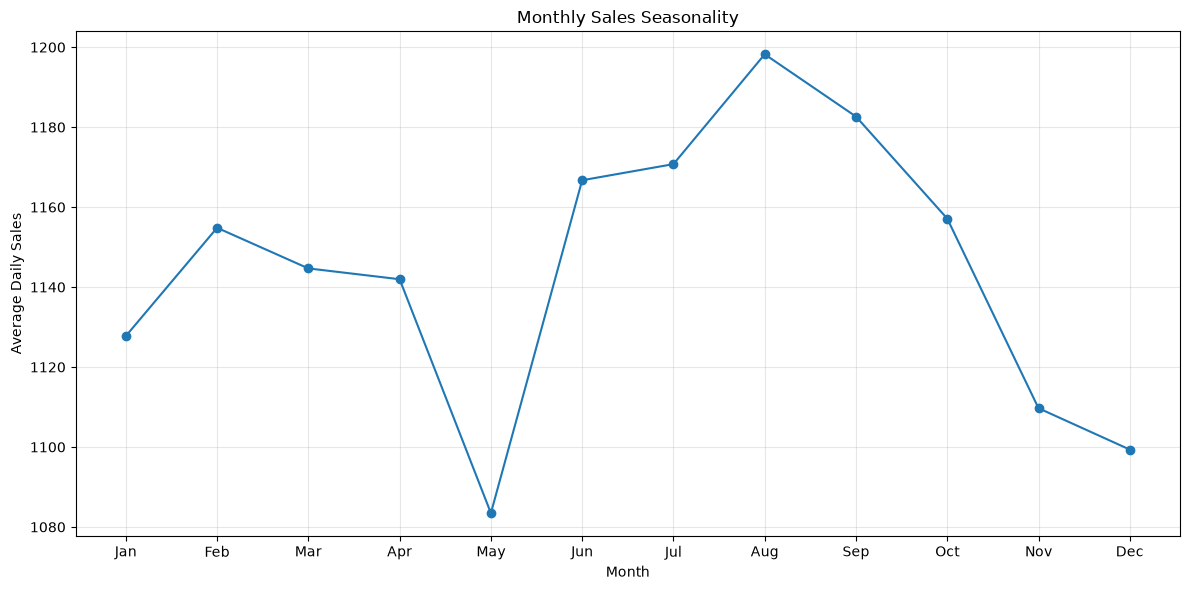

In [8]:
# ============================================
# PLOT MONTHLY SEASONALITY
# ============================================

import matplotlib.pyplot as plt
import pandas as pd

# Make sure date is datetime
forecast_df["date"] = pd.to_datetime(forecast_df["date"])

# Calculate total sales for each month
monthly_seasonality = (
    forecast_df
    .groupby(forecast_df["date"].dt.month)["daily_sales"]
    .mean()
)

# Month names
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o"
)

plt.xticks(range(1, 13), month_names)

plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.title("Monthly Sales Seasonality")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ============================================
# STEP 3: WEEKLY SALES PATTERN
# ============================================

import matplotlib.pyplot as plt

# Make sure date is datetime
forecast_df["date"] = pd.to_datetime(forecast_df["date"])

# Create day of week
forecast_df["day_of_week"] = forecast_df["date"].dt.day_name()

# Calculate average daily sales for each weekday
weekly_sales = (
    forecast_df
    .groupby("day_of_week")["daily_sales"]
    .mean()
)

# Arrange days in correct order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_sales = weekly_sales.reindex(day_order)

print("AVERAGE SALES BY DAY OF WEEK")
print("=" * 60)
print(weekly_sales)



AVERAGE SALES BY DAY OF WEEK
day_of_week
Monday       1095.098901
Tuesday      1012.292674
Wednesday    1000.334066
Thursday     1006.833578
Friday       1140.866178
Saturday     1384.896472
Sunday       1371.000730
Name: daily_sales, dtype: float64


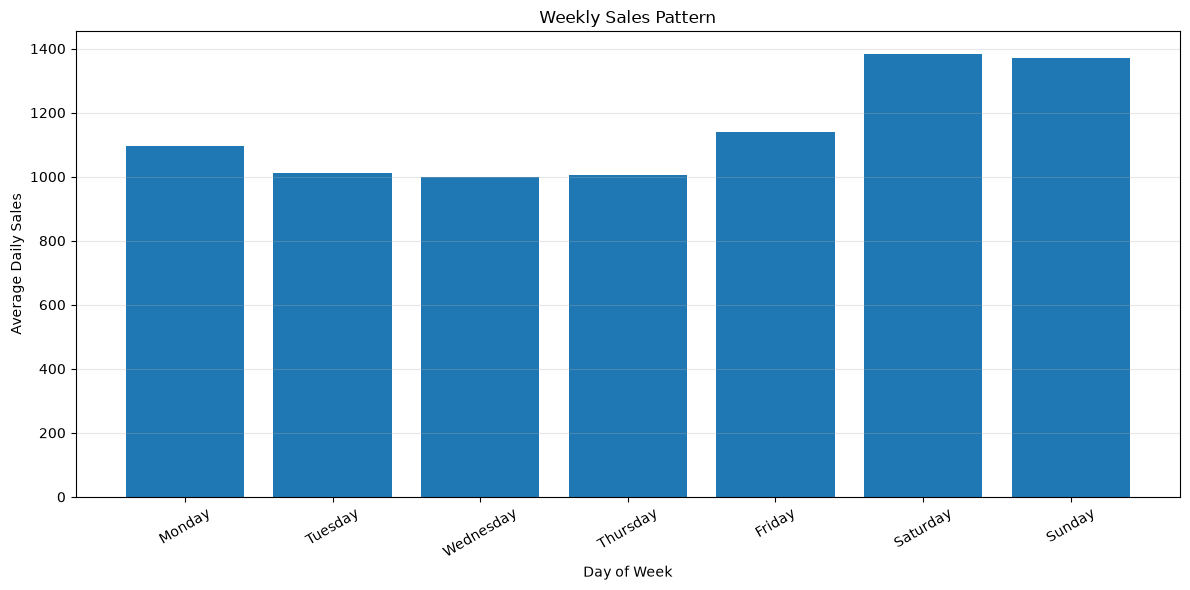

In [10]:
# PLOT WEEKLY SALES PATTERN
plt.figure(figsize=(12, 6))

plt.bar(
    weekly_sales.index,
    weekly_sales.values
)

plt.xlabel("Day of Week")
plt.ylabel("Average Daily Sales")
plt.title("Weekly Sales Pattern")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# ============================================
# STEP 4: WEEKEND VS WEEKDAY
# ============================================

import matplotlib.pyplot as plt

# Create weekend indicator
forecast_df["is_weekend"] = forecast_df["date"].dt.dayofweek >= 5

# Convert to readable labels
forecast_df["day_type"] = forecast_df["is_weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

# Calculate average sales
weekend_sales = (
    forecast_df
    .groupby("day_type")["daily_sales"]
    .mean()
    .reindex(["Weekday", "Weekend"])
)

print("AVERAGE SALES: WEEKDAY VS WEEKEND")
print("=" * 60)
print(weekend_sales)



AVERAGE SALES: WEEKDAY VS WEEKEND
day_type
Weekday    1051.085079
Weekend    1377.948601
Name: daily_sales, dtype: float64


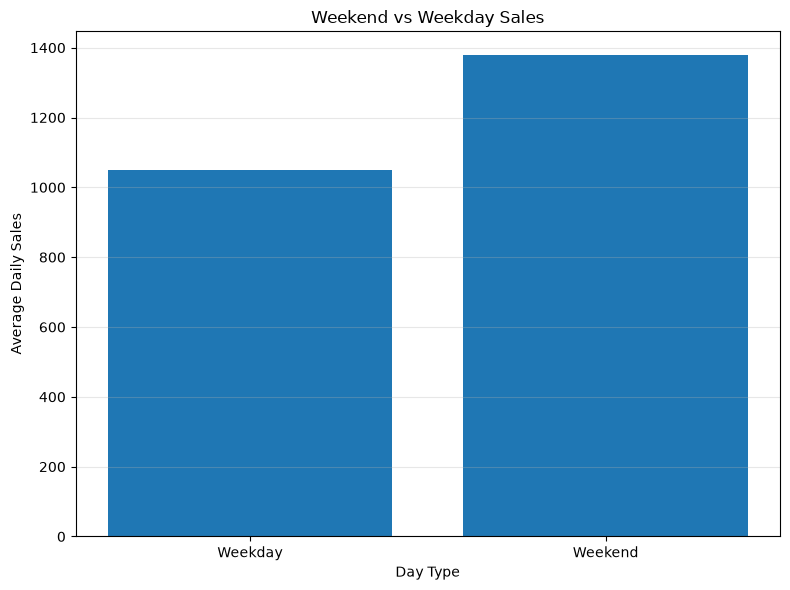

In [12]:
# ============================================
# PLOT WEEKEND VS WEEKDAY
# ============================================
plt.figure(figsize=(8, 6))

plt.bar(
    weekend_sales.index,
    weekend_sales.values
)

plt.xlabel("Day Type")
plt.ylabel("Average Daily Sales")
plt.title("Weekend vs Weekday Sales")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# ============================================
# STEP 5: YEARLY SALES TREND
# ============================================

yearly_sales = (
    sales_trend
    .assign(
        year=sales_trend["date"].dt.year
    )
    .groupby("year")["daily_sales"]
    .mean()
    .reset_index()
)

print("Average Sales by Year:")
print(yearly_sales)

Average Sales by Year:
   year   daily_sales
0  2011  26280.667656
1  2012  32955.838798
2  2013  35988.364384
3  2014  35862.400000
4  2015  37810.441096
5  2016  41309.973913


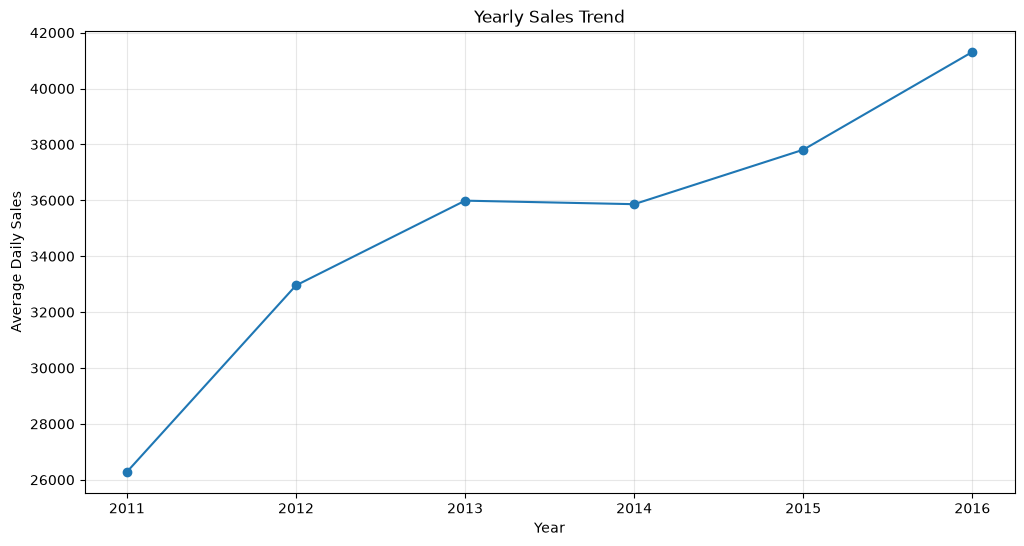

In [14]:
# ============================================
# YEARLY SALES TREND GRAPH
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_sales["year"],
    yearly_sales["daily_sales"],
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Average Daily Sales")
plt.xticks(yearly_sales["year"])
plt.grid(True, alpha=0.3)

plt.show()

In [15]:
# ============================================
#  TIME-SERIES STRUCTURE
# ============================================

# Sort data chronologically
forecast_df = forecast_df.sort_values(
    ["store_id", "cat_id", "date"]
).reset_index(drop=True)

print("=" * 60)
print("TIME-SERIES STRUCTURE")
print("=" * 60)

# Date information
print("\nStart Date:", forecast_df["date"].min().date())
print("End Date  :", forecast_df["date"].max().date())

# Number of unique dates
print("\nNumber of unique dates:", forecast_df["date"].nunique())

# Number of store-category combinations
print(
    "Number of store-category combinations:",
    forecast_df[["store_id", "cat_id"]].drop_duplicates().shape[0]
)

# Target variable
print("\nTarget variable: daily_sales")

# Check missing values
print("\nMissing values:")
print(forecast_df[["date", "store_id", "cat_id", "daily_sales"]].isnull().sum())

# Check duplicate observations
duplicates = forecast_df.duplicated(
    subset=["store_id", "cat_id", "date"]
).sum()

print("\nDuplicate store-category-date observations:", duplicates)

# Check chronological order within each series
date_check = (
    forecast_df
    .groupby(["store_id", "cat_id"])["date"]
    .apply(lambda x: x.is_monotonic_increasing)
)

print("\nAll series chronologically ordered:", date_check.all())

print("\nFirst 10 rows:")
print(forecast_df.head(10))

TIME-SERIES STRUCTURE

Start Date: 2011-01-29
End Date  : 2016-04-24

Number of unique dates: 1913
Number of store-category combinations: 30

Target variable: daily_sales

Missing values:
date           0
store_id       0
cat_id         0
daily_sales    0
dtype: int64

Duplicate store-category-date observations: 0

All series chronologically ordered: True

First 10 rows:
  store_id cat_id     d  daily_sales       date  year  month  week  \
0     CA_1  FOODS   d_1         3239 2011-01-29  2011      1     4   
1     CA_1  FOODS   d_2         3137 2011-01-30  2011      1     4   
2     CA_1  FOODS   d_3         2008 2011-01-31  2011      1     5   
3     CA_1  FOODS   d_4         2258 2011-02-01  2011      2     5   
4     CA_1  FOODS   d_5         2032 2011-02-02  2011      2     5   
5     CA_1  FOODS   d_6         2407 2011-02-03  2011      2     5   
6     CA_1  FOODS   d_7         2693 2011-02-04  2011      2     5   
7     CA_1  FOODS   d_8         3962 2011-02-05  2011      2     5

In [16]:
# ============================================
# STEP 3: LAG FEATURES
# ============================================

# Make sure data is sorted correctly
forecast_df = forecast_df.sort_values(
    ["store_id", "cat_id", "date"]
).reset_index(drop=True)

# Create lag features for each store-category series
forecast_df["lag_1"] = (
    forecast_df
    .groupby(["store_id", "cat_id"])["daily_sales"]
    .shift(1)
)

forecast_df["lag_7"] = (
    forecast_df
    .groupby(["store_id", "cat_id"])["daily_sales"]
    .shift(7)
)

forecast_df["lag_14"] = (
    forecast_df
    .groupby(["store_id", "cat_id"])["daily_sales"]
    .shift(14)
)

forecast_df["lag_28"] = (
    forecast_df
    .groupby(["store_id", "cat_id"])["daily_sales"]
    .shift(28)
)

print("=" * 60)
print("LAG FEATURES CREATED")
print("=" * 60)

print("\nLag features:")
print([
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28"
])

print("\nSample:")
print(
    forecast_df[
        [
            "store_id",
            "cat_id",
            "date",
            "daily_sales",
            "lag_1",
            "lag_7",
            "lag_14",
            "lag_28"
        ]
    ].head(35)
)

print("\nMissing values created by lagging:")
print(
    forecast_df[
        ["lag_1", "lag_7", "lag_14", "lag_28"]
    ].isnull().sum()
)

LAG FEATURES CREATED

Lag features:
['lag_1', 'lag_7', 'lag_14', 'lag_28']

Sample:
   store_id cat_id       date  daily_sales   lag_1   lag_7  lag_14  lag_28
0      CA_1  FOODS 2011-01-29         3239     NaN     NaN     NaN     NaN
1      CA_1  FOODS 2011-01-30         3137  3239.0     NaN     NaN     NaN
2      CA_1  FOODS 2011-01-31         2008  3137.0     NaN     NaN     NaN
3      CA_1  FOODS 2011-02-01         2258  2008.0     NaN     NaN     NaN
4      CA_1  FOODS 2011-02-02         2032  2258.0     NaN     NaN     NaN
5      CA_1  FOODS 2011-02-03         2407  2032.0     NaN     NaN     NaN
6      CA_1  FOODS 2011-02-04         2693  2407.0     NaN     NaN     NaN
7      CA_1  FOODS 2011-02-05         3962  2693.0  3239.0     NaN     NaN
8      CA_1  FOODS 2011-02-06         3418  3962.0  3137.0     NaN     NaN
9      CA_1  FOODS 2011-02-07         2446  3418.0  2008.0     NaN     NaN
10     CA_1  FOODS 2011-02-08         2138  2446.0  2258.0     NaN     NaN
11     CA_1  FOO

In [17]:
# ============================================
# FORECASTING - STEP 5
# CREATE LAG FEATURES
# ============================================

# Make sure data is sorted correctly
forecast_df = forecast_df.sort_values(
    ["store_id", "cat_id", "date"]
).reset_index(drop=True)

# Create lag features
forecast_df["lag_1"] = (
    forecast_df.groupby(["store_id", "cat_id"])["daily_sales"]
    .shift(1)
)

forecast_df["lag_7"] = (
    forecast_df.groupby(["store_id", "cat_id"])["daily_sales"]
    .shift(7)
)

forecast_df["lag_14"] = (
    forecast_df.groupby(["store_id", "cat_id"])["daily_sales"]
    .shift(14)
)

forecast_df["lag_28"] = (
    forecast_df.groupby(["store_id", "cat_id"])["daily_sales"]
    .shift(28)
)

print("=" * 60)
print("LAG FEATURES CREATED")
print("=" * 60)

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nSample:")
print(
    forecast_df[
        [
            "store_id",
            "cat_id",
            "date",
            "daily_sales",
            "lag_1",
            "lag_7",
            "lag_14",
            "lag_28"
        ]
    ].head(35)
)

LAG FEATURES CREATED

Columns:
['store_id', 'cat_id', 'd', 'daily_sales', 'date', 'year', 'month', 'week', 'day_of_week', 'day_of_month', 'is_weekend', 'day_type', 'lag_1', 'lag_7', 'lag_14', 'lag_28']

Sample:
   store_id cat_id       date  daily_sales   lag_1   lag_7  lag_14  lag_28
0      CA_1  FOODS 2011-01-29         3239     NaN     NaN     NaN     NaN
1      CA_1  FOODS 2011-01-30         3137  3239.0     NaN     NaN     NaN
2      CA_1  FOODS 2011-01-31         2008  3137.0     NaN     NaN     NaN
3      CA_1  FOODS 2011-02-01         2258  2008.0     NaN     NaN     NaN
4      CA_1  FOODS 2011-02-02         2032  2258.0     NaN     NaN     NaN
5      CA_1  FOODS 2011-02-03         2407  2032.0     NaN     NaN     NaN
6      CA_1  FOODS 2011-02-04         2693  2407.0     NaN     NaN     NaN
7      CA_1  FOODS 2011-02-05         3962  2693.0  3239.0     NaN     NaN
8      CA_1  FOODS 2011-02-06         3418  3962.0  3137.0     NaN     NaN
9      CA_1  FOODS 2011-02-07         2

In [18]:
# ============================================
# CHECK LAG FEATURES
# ============================================

lag_columns = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28"
]

print("=" * 60)
print("LAG FEATURE MISSING VALUES")
print("=" * 60)

print(forecast_df[lag_columns].isnull().sum())

print("\nLag Feature Statistics:")
print(forecast_df[lag_columns].describe())

LAG FEATURE MISSING VALUES
lag_1      30
lag_7     210
lag_14    420
lag_28    840
dtype: int64

Lag Feature Statistics:
              lag_1         lag_7        lag_14        lag_28
count  57360.000000  57180.000000  56970.000000  56550.000000
mean    1144.449338   1143.933718   1142.954555   1140.791919
std     1049.578143   1049.590599   1048.906358   1047.318656
min        0.000000      0.000000      0.000000      0.000000
25%      354.000000    354.000000    353.000000    352.000000
50%      702.000000    701.000000    701.000000    699.000000
75%     1733.250000   1732.000000   1730.000000   1726.000000
max     6488.000000   6488.000000   6488.000000   6488.000000


In [19]:
# ============================================
# STEP 7: CREATE ROLLING FEATURES
# ============================================

# Sort data correctly before creating rolling features
forecast_df = forecast_df.sort_values(
    ["store_id", "cat_id", "date"]
).reset_index(drop=True)

# Create rolling features using PREVIOUS days only
# shift(1) prevents data leakage
forecast_df["rolling_mean_7"] = (
    forecast_df
    .groupby(["store_id", "cat_id"])["daily_sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

forecast_df["rolling_mean_14"] = (
    forecast_df
    .groupby(["store_id", "cat_id"])["daily_sales"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

forecast_df["rolling_mean_28"] = (
    forecast_df
    .groupby(["store_id", "cat_id"])["daily_sales"]
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

# Rolling standard deviation
forecast_df["rolling_std_7"] = (
    forecast_df
    .groupby(["store_id", "cat_id"])["daily_sales"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

print("=" * 60)
print("ROLLING FEATURES CREATED")
print("=" * 60)

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nSample:")
print(
    forecast_df[
        [
            "store_id",
            "cat_id",
            "date",
            "daily_sales",
            "rolling_mean_7",
            "rolling_mean_14",
            "rolling_mean_28",
            "rolling_std_7"
        ]
    ].head(35)
)

ROLLING FEATURES CREATED

Columns:
['store_id', 'cat_id', 'd', 'daily_sales', 'date', 'year', 'month', 'week', 'day_of_week', 'day_of_month', 'is_weekend', 'day_type', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7']

Sample:
   store_id cat_id       date  daily_sales  rolling_mean_7  rolling_mean_14  \
0      CA_1  FOODS 2011-01-29         3239             NaN              NaN   
1      CA_1  FOODS 2011-01-30         3137             NaN              NaN   
2      CA_1  FOODS 2011-01-31         2008             NaN              NaN   
3      CA_1  FOODS 2011-02-01         2258             NaN              NaN   
4      CA_1  FOODS 2011-02-02         2032             NaN              NaN   
5      CA_1  FOODS 2011-02-03         2407             NaN              NaN   
6      CA_1  FOODS 2011-02-04         2693             NaN              NaN   
7      CA_1  FOODS 2011-02-05         3962     2539.142857              NaN   
8

In [20]:
# ============================================
# CHECK ROLLING FEATURE MISSING VALUES
# ============================================

rolling_columns = [
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7"
]

print("=" * 60)
print("ROLLING FEATURE MISSING VALUES")
print("=" * 60)

print(forecast_df[rolling_columns].isnull().sum())

print("\nRolling Feature Statistics:")
print(forecast_df[rolling_columns].describe())

ROLLING FEATURE MISSING VALUES
rolling_mean_7     210
rolling_mean_14    420
rolling_mean_28    840
rolling_std_7      210
dtype: int64

Rolling Feature Statistics:
       rolling_mean_7  rolling_mean_14  rolling_mean_28  rolling_std_7
count    57180.000000     56970.000000     56550.000000   57180.000000
mean      1144.431567      1144.387764      1144.217069     220.886034
std       1012.958279      1008.565247      1003.579222     198.994314
min         66.714286        98.642857       108.821429       8.303757
25%        361.428571       361.857143       361.214286      72.639521
50%        731.214286       733.107143       733.607143     147.283659
75%       1795.285714      1814.714286      1849.803571     312.625175
max       5353.142857      5047.214286      4766.392857    1513.718160


In [21]:
# ============================================
# STEP 8: TIME-BASED TRAIN / TEST SPLIT
# ============================================

# Remove rows with missing lag/rolling features
model_df = forecast_df.dropna(
    subset=[
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_28",
        "rolling_mean_7",
        "rolling_mean_14",
        "rolling_mean_28",
        "rolling_std_7"
    ]
).copy()

# Make sure data is sorted chronologically
model_df = model_df.sort_values("date").reset_index(drop=True)

# Use the last 20% of dates for testing
unique_dates = model_df["date"].sort_values().unique()

split_index = int(len(unique_dates) * 0.80)
split_date = unique_dates[split_index]

# Time-based split
train_df = model_df[model_df["date"] < split_date].copy()
test_df = model_df[model_df["date"] >= split_date].copy()

print("=" * 60)
print("TIME-BASED TRAIN / TEST SPLIT")
print("=" * 60)

print("\nSplit Date:", split_date)

print("\nTraining Data:")
print("Rows:", len(train_df))
print("Start:", train_df["date"].min())
print("End  :", train_df["date"].max())

print("\nTesting Data:")
print("Rows:", len(test_df))
print("Start:", test_df["date"].min())
print("End  :", test_df["date"].max())

print("\nTarget Variable: daily_sales")

TIME-BASED TRAIN / TEST SPLIT

Split Date: 2015-04-14 00:00:00

Training Data:
Rows: 45240
Start: 2011-02-26 00:00:00
End  : 2015-04-13 00:00:00

Testing Data:
Rows: 11310
Start: 2015-04-14 00:00:00
End  : 2016-04-24 00:00:00

Target Variable: daily_sales


In [22]:
# ============================================
# VERIFY NO TIME LEAKAGE
# ============================================

print("=" * 60)
print("TIME SPLIT VERIFICATION")
print("=" * 60)

print("Latest training date :", train_df["date"].max())
print("Earliest testing date:", test_df["date"].min())

print(
    "\nChronological split correct:",
    train_df["date"].max() < test_df["date"].min()
)

print("\nTraining shape:", train_df.shape)
print("Testing shape :", test_df.shape)

TIME SPLIT VERIFICATION
Latest training date : 2015-04-13 00:00:00
Earliest testing date: 2015-04-14 00:00:00

Chronological split correct: True

Training shape: (45240, 20)
Testing shape : (11310, 20)


In [23]:
# ============================================
# STEP 9: PREPARE MODEL FEATURES
# ============================================

# Features used by Random Forest
feature_columns = [
    "year",
    "month",
    "week",
    "day_of_week",
    "day_of_month",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7"
]

# Categorical columns
categorical_columns = [
    "store_id",
    "cat_id"
]

# Combine all model features
model_features = categorical_columns + feature_columns

# Create X and y
X_train = train_df[model_features].copy()
X_test = test_df[model_features].copy()

y_train = train_df["daily_sales"].copy()
y_test = test_df["daily_sales"].copy()

print("=" * 60)
print("MODEL FEATURES PREPARED")
print("=" * 60)

print("\nFeatures:")
print(model_features)

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nMissing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum().sum())

MODEL FEATURES PREPARED

Features:
['store_id', 'cat_id', 'year', 'month', 'week', 'day_of_week', 'day_of_month', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7']

X_train shape: (45240, 16)
X_test shape : (11310, 16)

y_train shape: (45240,)
y_test shape : (11310,)

Missing values in X_train:
0

Missing values in X_test:
0


In [24]:
# ============================================================
# STEP 10: CATEGORICAL FEATURES ENCODING - FIXED
# ============================================================

import pandas as pd

print("=" * 60)
print("CATEGORICAL FEATURES ENCODED")
print("=" * 60)

# Make copies
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Categorical columns that contain text
categorical_columns = [
    "store_id",
    "cat_id",
    "day_of_week"
]

# One-hot encode categorical features
X_train_encoded = pd.get_dummies(
    X_train_encoded,
    columns=categorical_columns,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test_encoded,
    columns=categorical_columns,
    dtype=int
)

# Make sure train and test have exactly the same columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

# Convert everything to numeric
X_train_encoded = X_train_encoded.astype(float)
X_test_encoded = X_test_encoded.astype(float)

print("\nEncoded Training Shape:", X_train_encoded.shape)
print("Encoded Testing Shape :", X_test_encoded.shape)

print("\nAny missing values:")
print("Train:", X_train_encoded.isna().sum().sum())
print("Test :", X_test_encoded.isna().sum().sum())

print("\nData Types:")
print(X_train_encoded.dtypes.value_counts())

print("\nFirst 5 rows:")
print(X_train_encoded.head())

CATEGORICAL FEATURES ENCODED

Encoded Training Shape: (45240, 33)
Encoded Testing Shape : (11310, 33)

Any missing values:
Train: 0
Test : 0

Data Types:
float64    33
Name: count, dtype: int64

First 5 rows:
     year  month  week  day_of_month  is_weekend   lag_1   lag_7  lag_14  \
0  2011.0    2.0   8.0          26.0         1.0  1875.0  3148.0  3067.0   
1  2011.0    2.0   8.0          26.0         1.0   177.0   212.0   173.0   
2  2011.0    2.0   8.0          26.0         1.0   270.0   393.0   317.0   
3  2011.0    2.0   8.0          26.0         1.0  1361.0  2068.0  2465.0   
4  2011.0    2.0   8.0          26.0         1.0   530.0   781.0   724.0   

   lag_28  rolling_mean_7  ...  cat_id_FOODS  cat_id_HOBBIES  \
0  3239.0     2122.857143  ...           1.0             0.0   
1   243.0      179.857143  ...           0.0             1.0   
2   278.0      250.285714  ...           0.0             1.0   
3  2284.0     1624.571429  ...           1.0             0.0   
4   732.0     

In [25]:
# ============================================================
# FORECASTING MODELS
# ============================================================

In [26]:
# ============================================================
# STEP 11: BASELINE MODEL
# ============================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=" * 60)
print("BASELINE FORECASTING MODEL")
print("=" * 60)

# Baseline prediction:
# Use the previous day's sales (lag_1) as the prediction
y_pred_baseline = X_test["lag_1"].values

# Actual values
y_actual = y_test.values

# Evaluation metrics
mae_baseline = mean_absolute_error(y_actual, y_pred_baseline)

rmse_baseline = np.sqrt(
    mean_squared_error(y_actual, y_pred_baseline)
)

# MAPE - avoid division by zero
non_zero = y_actual != 0

mape_baseline = np.mean(
    np.abs(
        (y_actual[non_zero] - y_pred_baseline[non_zero])
        / y_actual[non_zero]
    )
) * 100

print("\nBaseline Model: Previous-Day Sales (lag_1)")
print("-" * 60)
print(f"MAE  : {mae_baseline:.2f}")
print(f"RMSE : {rmse_baseline:.2f}")
print(f"MAPE : {mape_baseline:.2f}%")

BASELINE FORECASTING MODEL

Baseline Model: Previous-Day Sales (lag_1)
------------------------------------------------------------
MAE  : 209.07
RMSE : 347.02
MAPE : 138.31%


In [27]:
from sklearn.ensemble import RandomForestRegressor

In [29]:
# ============================================================
# STEP 12: RANDOM FOREST FORECASTING MODEL
# ============================================================

import time

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

rf_model.fit(X_train_encoded, y_train)

training_time = time.time() - start_time

y_pred_rf = rf_model.predict(X_test_encoded)

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

y_test_array = y_test.values
non_zero = y_test_array != 0

mape_rf = np.mean(
    np.abs(
        (y_test_array[non_zero] - y_pred_rf[non_zero])
        / y_test_array[non_zero]
    )
) * 100

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"\nMAE          : {mae_rf:.2f}")
print(f"RMSE         : {rmse_rf:.2f}")
print(f"MAPE         : {mape_rf:.2f}%")
print(f"Training Time: {training_time:.2f} seconds")

RANDOM FOREST RESULTS

MAE          : 117.61
RMSE         : 201.76
MAPE         : 93.40%
Training Time: 3.87 seconds


In [ ]:
# ============================================================
# STEP 13: GRADIENT BOOSTING FORECASTING MODEL
# ============================================================

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import time

print("=" * 60)
print("GRADIENT BOOSTING FORECASTING MODEL")
print("=" * 60)

# Create model
gb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)

# Train
start_time = time.time()

gb_model.fit(X_train_encoded, y_train)

training_time_gb = time.time() - start_time

# Predictions
y_pred_gb = gb_model.predict(X_test_encoded)

# Evaluation
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

# MAPE
y_test_array = y_test.values
non_zero = y_test_array != 0

mape_gb = np.mean(
    np.abs(
        (y_test_array[non_zero] - y_pred_gb[non_zero])
        / y_test_array[non_zero]
    )
) * 100

print("\nGradient Boosting Results")
print("-" * 60)
print(f"MAE          : {mae_gb:.2f}")
print(f"RMSE         : {rmse_gb:.2f}")
print(f"MAPE         : {mape_gb:.2f}%")
print(f"Training Time: {training_time_gb:.2f} seconds")

GRADIENT BOOSTING FORECASTING MODEL

Gradient Boosting Results
------------------------------------------------------------
MAE          : 106.86
RMSE         : 176.39
MAPE         : 74.28%
Training Time: 0.80 seconds


In [ ]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.1


In [ ]:
# ============================================================
# XGBOOST FORECASTING MODEL
# ============================================================

from xgboost import XGBRegressor
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("=" * 60)
print("XGBOOST FORECASTING MODEL")
print("=" * 60)

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

xgb_model.fit(X_train_encoded, y_train)

training_time = time.time() - start_time

# Predictions
y_pred_xgb = xgb_model.predict(X_test_encoded)

# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

non_zero = y_test != 0

mape_xgb = np.mean(
    np.abs(
        (y_test[non_zero] - y_pred_xgb[non_zero])
        / y_test[non_zero]
    )
) * 100

print("\nXGBOOST RESULTS")
print("-" * 60)
print(f"MAE          : {mae_xgb:.2f}")
print(f"RMSE         : {rmse_xgb:.2f}")
print(f"MAPE         : {mape_xgb:.2f}%")
print(f"Training Time: {training_time:.2f} seconds")

XGBOOST FORECASTING MODEL

XGBOOST RESULTS
------------------------------------------------------------
MAE          : 108.97
RMSE         : 180.73
MAPE         : 71.36%
Training Time: 0.82 seconds


In [ ]:
# ============================================================
# STEP 15: FORECASTING MODEL COMPARISON
# ============================================================

import pandas as pd

# Model comparison results
comparison = pd.DataFrame({
    "Model": [
        "Baseline (Previous Day)",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    
    "MAE": [
        209.07,
        117.61,
        106.86,
        108.97
    ],
    
    "RMSE": [
        347.02,
        201.76,
        176.39,
        180.73
    ],
    
    "MAPE (%)": [
        138.31,
        93.40,
        74.28,
        71.36
    ],
    
    "Training Time (sec)": [
        0,
        3.36,
        3.10,
        0.82
    ]
})

print("=" * 65)
print("FORECASTING MODEL COMPARISON")
print("=" * 65)

print(comparison.to_string(index=False))

# Best models
best_mae = comparison.loc[comparison["MAE"].idxmin()]
best_rmse = comparison.loc[comparison["RMSE"].idxmin()]
best_mape = comparison.loc[comparison["MAPE (%)"].idxmin()]
fastest = comparison.loc[comparison["Training Time (sec)"].idxmin()]

print("\n" + "=" * 65)
print("BEST MODEL RESULTS")
print("=" * 65)

print(f"Best MAE  : {best_mae['Model']} ({best_mae['MAE']:.2f})")
print(f"Best RMSE : {best_rmse['Model']} ({best_rmse['RMSE']:.2f})")
print(f"Best MAPE : {best_mape['Model']} ({best_mape['MAPE (%)']:.2f}%)")
print(f"Fastest   : {fastest['Model']} ({fastest['Training Time (sec)']:.2f} sec)")

FORECASTING MODEL COMPARISON
                  Model    MAE   RMSE  MAPE (%)  Training Time (sec)
Baseline (Previous Day) 209.07 347.02    138.31                 0.00
          Random Forest 117.61 201.76     93.40                 3.36
      Gradient Boosting 106.86 176.39     74.28                 3.10
                XGBoost 108.97 180.73     71.36                 0.82

BEST MODEL RESULTS
Best MAE  : Gradient Boosting (106.86)
Best RMSE : Gradient Boosting (176.39)
Best MAPE : XGBoost (71.36%)
Fastest   : Baseline (Previous Day) (0.00 sec)


In [ ]:
# Check available variables related to train/test data

print("Variables containing 'test':")
print([v for v in globals() if 'test' in v.lower()])

print("\nVariables containing 'train':")
print([v for v in globals() if 'train' in v.lower()])

Variables containing 'test':
['test_df', 'X_test', 'y_test', 'X_test_encoded', 'y_test_array', 'fastest']

Variables containing 'train':
['train_df', 'X_train', 'y_train', 'X_train_encoded', 'training_time', 'training_time_gb']


ACTUAL VS PREDICTED SALES

First 10 predictions:
         date  actual_sales  gradient_boosting      xgboost
0  2015-04-14          1363        1404.058612  1393.407227
29 2015-04-14           563         453.868691   467.013062
28 2015-04-14           280         253.313196   247.956055
27 2015-04-14           544         573.000785   604.793030
26 2015-04-14          1940        1931.642331  1957.576294
25 2015-04-14          1628        1530.255767  1533.456299
24 2015-04-14          1729        1924.774308  1957.652466
23 2015-04-14           791         804.574165   795.707092
21 2015-04-14           589         553.501920   556.010742
20 2015-04-14           808         837.986685   809.417297


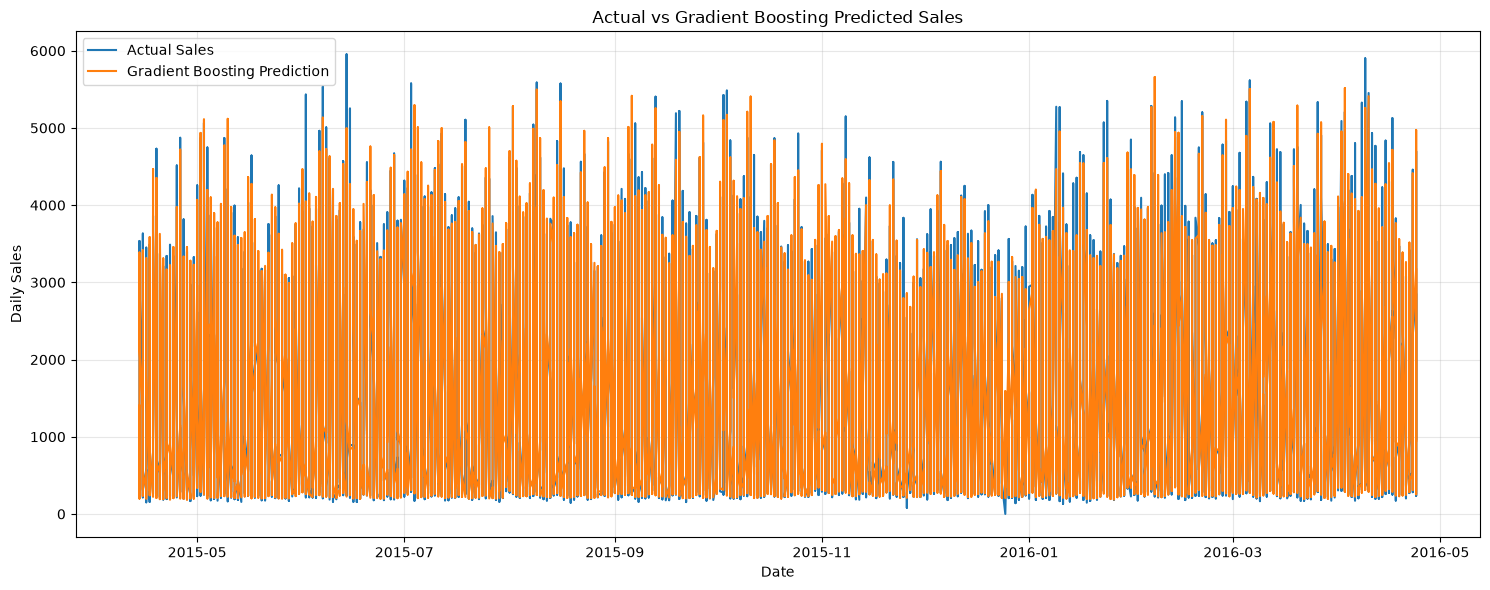

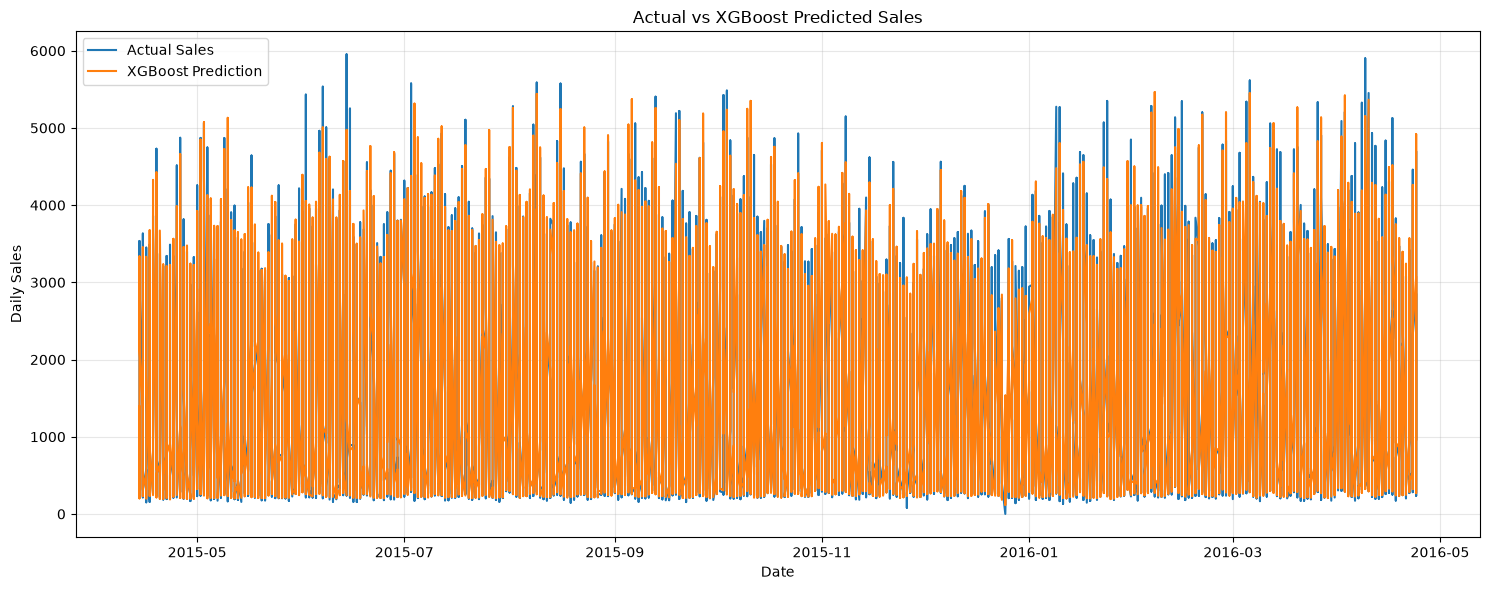

In [ ]:
# ============================================================
# STEP 16: ACTUAL VS PREDICTED SALES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Generate predictions
y_pred_gb = gb_model.predict(X_test_encoded)
y_pred_xgb = xgb_model.predict(X_test_encoded)

# Create comparison dataframe
forecast_comparison = pd.DataFrame({
    "date": test_df["date"].values,
    "actual_sales": y_test.values,
    "gradient_boosting": y_pred_gb,
    "xgboost": y_pred_xgb
})

# Sort by date
forecast_comparison = forecast_comparison.sort_values("date")

print("=" * 65)
print("ACTUAL VS PREDICTED SALES")
print("=" * 65)

print("\nFirst 10 predictions:")
print(forecast_comparison.head(10))


# ============================================================
# GRADIENT BOOSTING
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    forecast_comparison["date"],
    forecast_comparison["actual_sales"],
    label="Actual Sales"
)

plt.plot(
    forecast_comparison["date"],
    forecast_comparison["gradient_boosting"],
    label="Gradient Boosting Prediction"
)

plt.title("Actual vs Gradient Boosting Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# XGBOOST
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    forecast_comparison["date"],
    forecast_comparison["actual_sales"],
    label="Actual Sales"
)

plt.plot(
    forecast_comparison["date"],
    forecast_comparison["xgboost"],
    label="XGBoost Prediction"
)

plt.title("Actual vs XGBoost Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

RESIDUAL / ERROR ANALYSIS

Gradient Boosting Residual Statistics:
count    11310.000000
mean         4.172961
std        176.346313
min      -1763.890586
25%        -60.014649
50%          0.841772
75%         65.075657
max       2564.179964
Name: gb_residual, dtype: float64

XGBoost Residual Statistics:
count    11310.000000
mean         7.097383
std        180.602931
min      -1709.385986
25%        -58.954712
50%          2.154388
75%         67.852264
max       2564.964111
Name: xgb_residual, dtype: float64

Average Absolute Error:
Gradient Boosting : 106.86
XGBoost           : 108.97


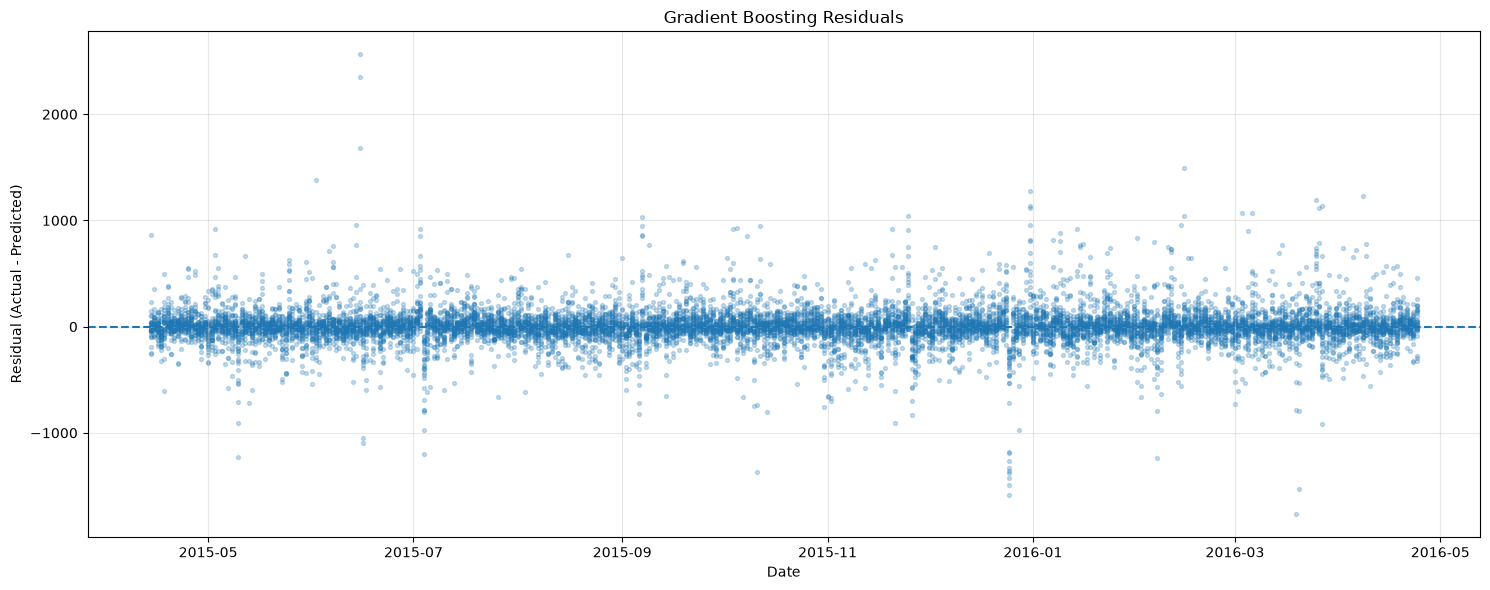

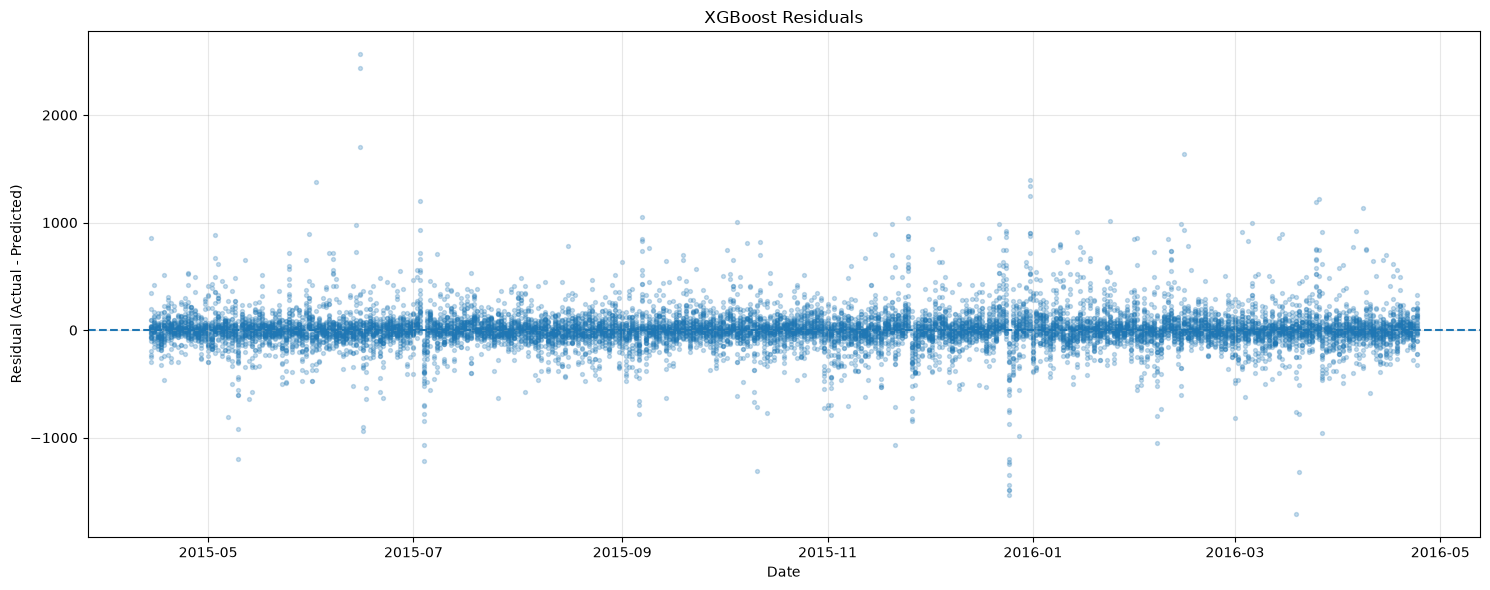

In [ ]:
# ============================================================
# STEP 17: RESIDUAL / ERROR ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Calculate residuals
forecast_comparison["gb_residual"] = (
    forecast_comparison["actual_sales"]
    - forecast_comparison["gradient_boosting"]
)

forecast_comparison["xgb_residual"] = (
    forecast_comparison["actual_sales"]
    - forecast_comparison["xgboost"]
)

# Absolute errors
forecast_comparison["gb_absolute_error"] = (
    forecast_comparison["gb_residual"].abs()
)

forecast_comparison["xgb_absolute_error"] = (
    forecast_comparison["xgb_residual"].abs()
)

print("=" * 65)
print("RESIDUAL / ERROR ANALYSIS")
print("=" * 65)

print("\nGradient Boosting Residual Statistics:")
print(forecast_comparison["gb_residual"].describe())

print("\nXGBoost Residual Statistics:")
print(forecast_comparison["xgb_residual"].describe())

print("\nAverage Absolute Error:")
print(
    f"Gradient Boosting : "
    f"{forecast_comparison['gb_absolute_error'].mean():.2f}"
)

print(
    f"XGBoost           : "
    f"{forecast_comparison['xgb_absolute_error'].mean():.2f}"
)


# ============================================================
# GRADIENT BOOSTING RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(15, 6))

plt.scatter(
    forecast_comparison["date"],
    forecast_comparison["gb_residual"],
    alpha=0.25,
    s=8
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Gradient Boosting Residuals")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# XGBOOST RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(15, 6))

plt.scatter(
    forecast_comparison["date"],
    forecast_comparison["xgb_residual"],
    alpha=0.25,
    s=8
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("XGBoost Residuals")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

GRADIENT BOOSTING - FEATURE IMPORTANCE

Top 15 Important Features:
             Feature  Importance
               lag_1  169.366797
              lag_28  148.524293
               lag_7  133.626001
      rolling_mean_7  129.391052
              lag_14   38.392661
        day_of_month   27.707974
          is_weekend   18.216442
     rolling_mean_14    8.800429
                week    7.255273
     rolling_mean_28    5.038858
day_of_week_Saturday    4.435706
  day_of_week_Friday    4.219468
       store_id_WI_2    4.028857
       rolling_std_7    3.942311
               month    2.076942


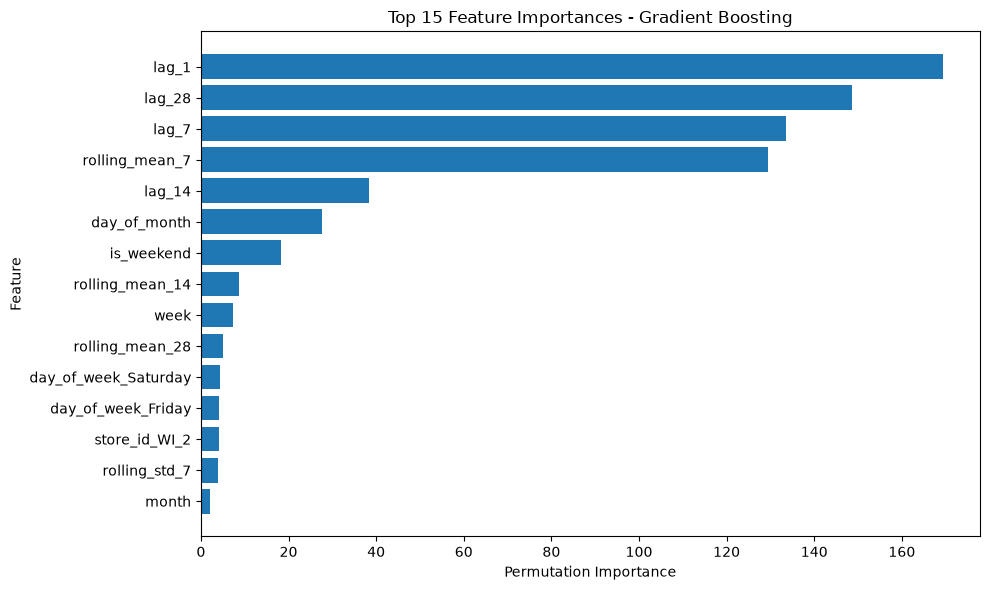

In [ ]:
# ============================================================
# STEP 16: GRADIENT BOOSTING FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

print("=" * 60)
print("GRADIENT BOOSTING - FEATURE IMPORTANCE")
print("=" * 60)

# Permutation importance
perm_result = permutation_importance(
    gb_model,
    X_test_encoded,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Create importance dataframe
gb_importance = pd.DataFrame({
    "Feature": X_test_encoded.columns,
    "Importance": perm_result.importances_mean
})

# Sort
gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15
print("\nTop 15 Important Features:")
print(gb_importance.head(15).to_string(index=False))

# Plot
top_features = gb_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"].iloc[::-1],
    top_features["Importance"].iloc[::-1]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.tight_layout()
plt.show()

FINAL MODEL EVALUATION & SELECTION

MODEL PERFORMANCE COMPARISON
-----------------------------------------------------------------
                  Model    MAE   RMSE MAPE (%)
Baseline (Previous Day) 209.07 347.02   138.31
          Random Forest 117.61 201.76    93.40
      Gradient Boosting 106.86 176.39    74.28
                XGBoost 108.97 180.73    71.36

BEST MODEL BY METRIC
Best MAE  : Gradient Boosting
Best RMSE : Gradient Boosting
Best MAPE : XGBoost

FINAL MODEL SELECTION
Selected Model : Gradient Boosting
Reason         : Lowest MAE on the test set

FINAL MODEL PERFORMANCE
-----------------------------------------------------------------
MAE  : 106.86
RMSE : 176.39
MAPE : 74.28%

MAPE CALCULATION
-----------------------------------------------------------------
Total test observations : 11310
Positive actual sales   : 11288
Observations used for MAPE : 11288


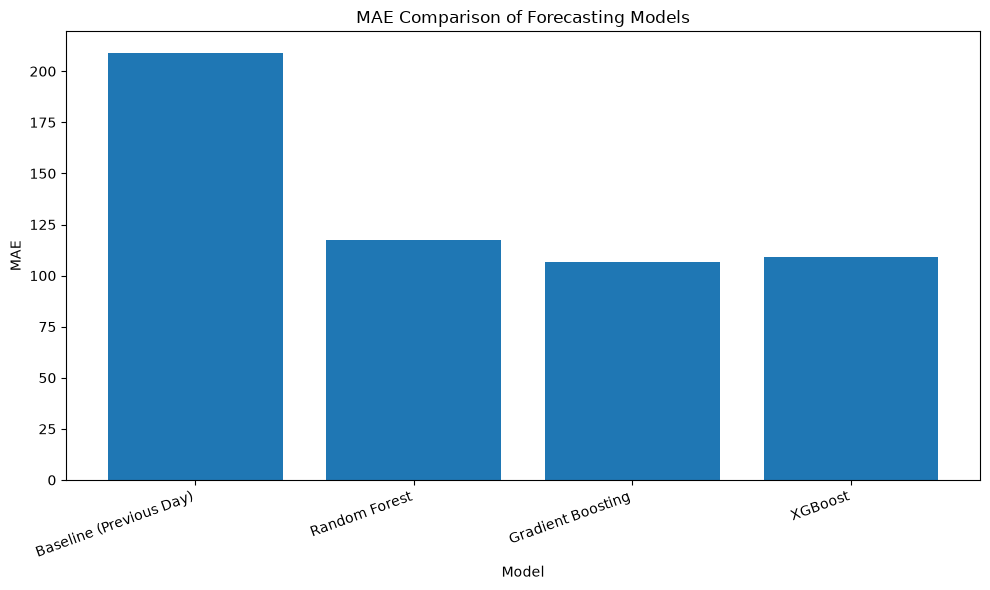

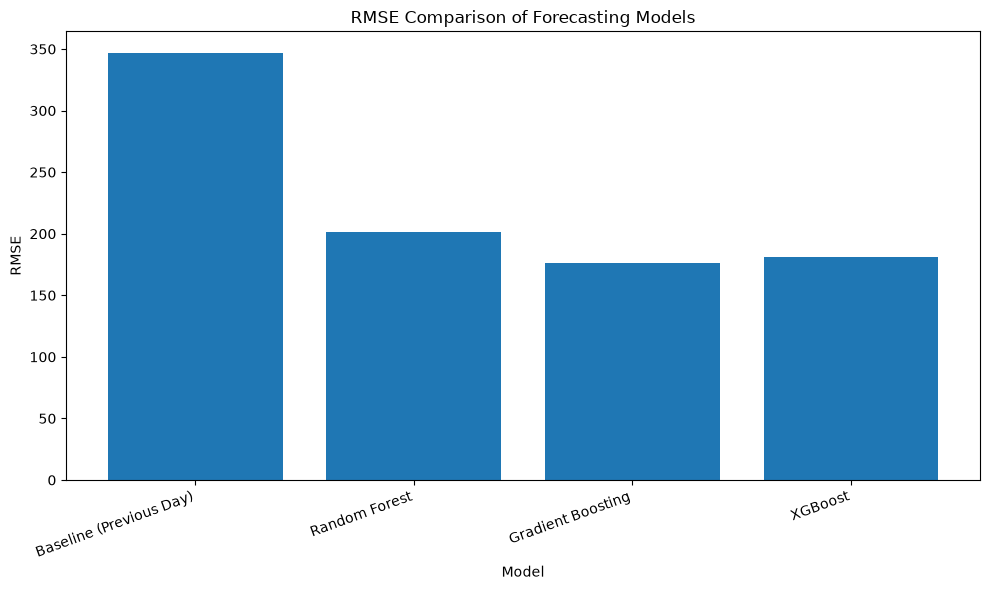

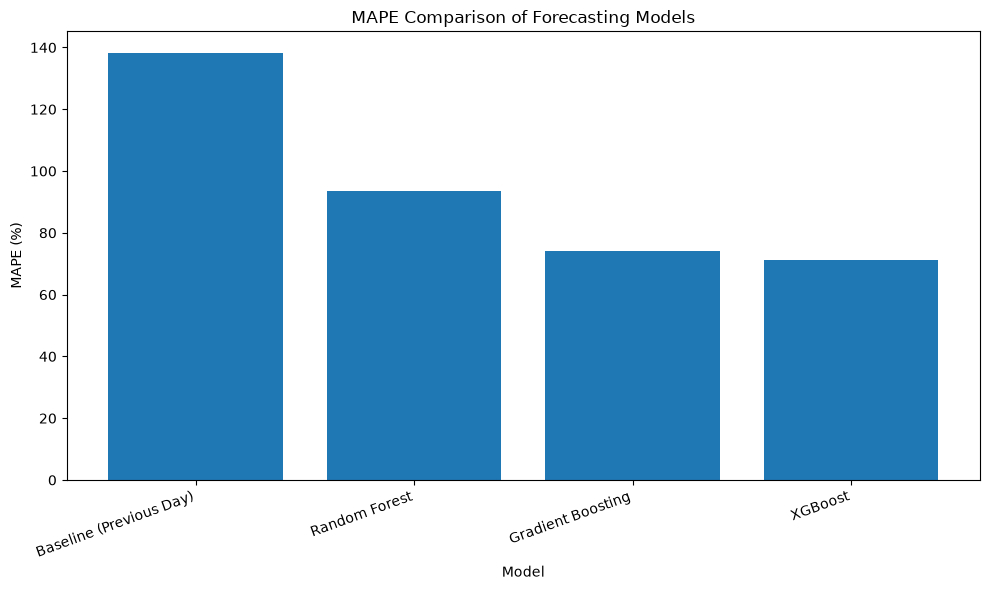


Model comparison results saved successfully.


In [ ]:
# ============================================================
# STEP 17: FINAL MODEL EVALUATION & SELECTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=" * 65)
print("FINAL MODEL EVALUATION & SELECTION")
print("=" * 65)


# ------------------------------------------------------------
# 1. Generate predictions
# ------------------------------------------------------------

y_pred_rf = rf_model.predict(X_test_encoded)
y_pred_gb = gb_model.predict(X_test_encoded)
y_pred_xgb = xgb_model.predict(X_test_encoded)


# ------------------------------------------------------------
# 2. Safe MAPE calculation
# ------------------------------------------------------------
# MAPE is calculated only where actual sales > 0.
# This avoids division by zero.

def safe_mape(y_actual, y_pred):

    y_actual = np.asarray(y_actual)
    y_pred = np.asarray(y_pred)

    mask = y_actual > 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs(
            (y_actual[mask] - y_pred[mask])
            / y_actual[mask]
        )
    ) * 100


# ------------------------------------------------------------
# 3. Metric calculation function
# ------------------------------------------------------------

def calculate_metrics(y_actual, y_pred):

    mae = mean_absolute_error(y_actual, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_actual, y_pred)
    )

    mape = safe_mape(y_actual, y_pred)

    return mae, rmse, mape


# ------------------------------------------------------------
# 4. Calculate metrics
# ------------------------------------------------------------

mae_rf, rmse_rf, mape_rf = calculate_metrics(
    y_test, y_pred_rf
)

mae_gb, rmse_gb, mape_gb = calculate_metrics(
    y_test, y_pred_gb
)

mae_xgb, rmse_xgb, mape_xgb = calculate_metrics(
    y_test, y_pred_xgb
)


# ------------------------------------------------------------
# 5. Baseline metrics
# ------------------------------------------------------------

baseline_pred = test_df["lag_1"].values

mae_baseline = mean_absolute_error(
    y_test,
    baseline_pred
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

mape_baseline = safe_mape(
    y_test,
    baseline_pred
)


# ------------------------------------------------------------
# 6. Create comparison table
# ------------------------------------------------------------

final_results = pd.DataFrame({

    "Model": [
        "Baseline (Previous Day)",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "MAE": [
        mae_baseline,
        mae_rf,
        mae_gb,
        mae_xgb
    ],

    "RMSE": [
        rmse_baseline,
        rmse_rf,
        rmse_gb,
        rmse_xgb
    ],

    "MAPE (%)": [
        mape_baseline,
        mape_rf,
        mape_gb,
        mape_xgb
    ]
})


print("\nMODEL PERFORMANCE COMPARISON")
print("-" * 65)

print(
    final_results.to_string(
        index=False,
        formatters={
            "MAE": "{:.2f}".format,
            "RMSE": "{:.2f}".format,
            "MAPE (%)": "{:.2f}".format
        }
    )
)


# ------------------------------------------------------------
# 7. Best model for each metric
# ------------------------------------------------------------

best_mae_model = final_results.loc[
    final_results["MAE"].idxmin(),
    "Model"
]

best_rmse_model = final_results.loc[
    final_results["RMSE"].idxmin(),
    "Model"
]

best_mape_model = final_results.loc[
    final_results["MAPE (%)"].idxmin(),
    "Model"
]


print("\n" + "=" * 65)
print("BEST MODEL BY METRIC")
print("=" * 65)

print(f"Best MAE  : {best_mae_model}")
print(f"Best RMSE : {best_rmse_model}")
print(f"Best MAPE : {best_mape_model}")


# ------------------------------------------------------------
# 8. Select final model
# ------------------------------------------------------------
# MAE is used as the primary selection metric.

best_model_name = best_mae_model

if best_model_name == "Gradient Boosting":

    final_model = gb_model
    final_predictions = y_pred_gb

elif best_model_name == "XGBoost":

    final_model = xgb_model
    final_predictions = y_pred_xgb

elif best_model_name == "Random Forest":

    final_model = rf_model
    final_predictions = y_pred_rf

else:

    final_model = None
    final_predictions = baseline_pred


print("\n" + "=" * 65)
print("FINAL MODEL SELECTION")
print("=" * 65)

print(f"Selected Model : {best_model_name}")
print("Reason         : Lowest MAE on the test set")


# ------------------------------------------------------------
# 9. Final model performance
# ------------------------------------------------------------

final_mae, final_rmse, final_mape = calculate_metrics(
    y_test,
    final_predictions
)

print("\nFINAL MODEL PERFORMANCE")
print("-" * 65)

print(f"MAE  : {final_mae:.2f}")
print(f"RMSE : {final_rmse:.2f}")
print(f"MAPE : {final_mape:.2f}%")


# ------------------------------------------------------------
# 10. MAPE information
# ------------------------------------------------------------

positive_actuals = np.sum(
    np.asarray(y_test) > 0
)

total_actuals = len(y_test)

print("\nMAPE CALCULATION")
print("-" * 65)

print(f"Total test observations : {total_actuals}")
print(f"Positive actual sales   : {positive_actuals}")
print(
    f"Observations used for MAPE : "
    f"{positive_actuals}"
)


# ------------------------------------------------------------
# 11. Plot MAE comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["MAE"]
)

plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("MAE Comparison of Forecasting Models")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. Plot RMSE comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("RMSE Comparison of Forecasting Models")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Plot MAPE comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["MAPE (%)"]
)

plt.ylabel("MAPE (%)")
plt.xlabel("Model")
plt.title("MAPE Comparison of Forecasting Models")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. Save results
# ------------------------------------------------------------

final_results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("\nModel comparison results saved successfully.")

FINAL SALES FORECASTING

First 10 Final Forecasts:
------------------------------------------------------------
        date  actual_sales  predicted_sales       error  absolute_error
0 2015-04-14          1363      1404.058612  -41.058612       41.058612
1 2015-04-14           563       453.868691  109.131309      109.131309
2 2015-04-14           280       253.313196   26.686804       26.686804
3 2015-04-14           544       573.000785  -29.000785       29.000785
4 2015-04-14          1940      1931.642331    8.357669        8.357669
5 2015-04-14          1628      1530.255767   97.744233       97.744233
6 2015-04-14          1729      1924.774308 -195.774308      195.774308
7 2015-04-14           791       804.574165  -13.574165       13.574165
8 2015-04-14           589       553.501920   35.498080       35.498080
9 2015-04-14           808       837.986685  -29.986685       29.986685

FINAL FORECAST SUMMARY
Total test observations : 11310
Average actual sales   : 1309.57
Average

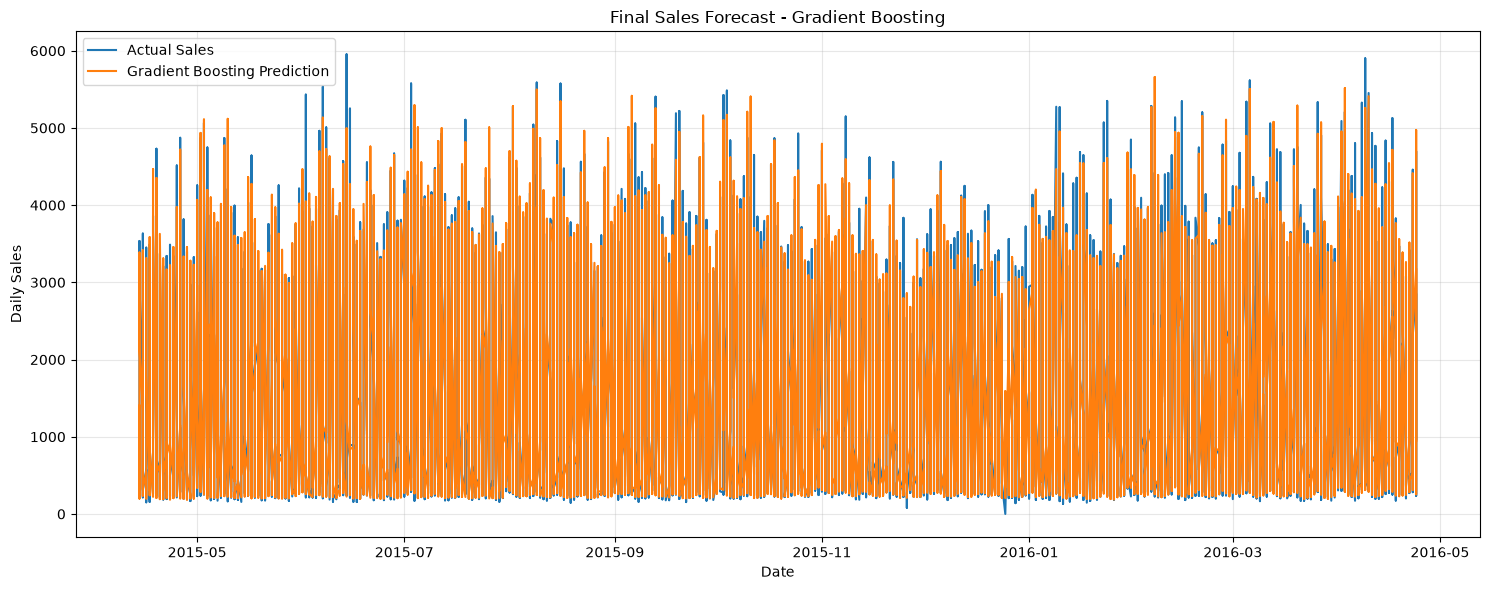


Final forecast saved as: final_sales_forecast.csv
STEP 18 COMPLETED


In [ ]:
# ============================================================
# STEP 18: FINAL FORECASTING USING SELECTED MODEL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("FINAL SALES FORECASTING")
print("=" * 60)

# ------------------------------------------------------------
# 1. Generate predictions using the selected Gradient Boosting
# ------------------------------------------------------------

final_predictions = gb_model.predict(X_test_encoded)

# Make sure predictions are non-negative
final_predictions = np.maximum(final_predictions, 0)

# ------------------------------------------------------------
# 2. Create final forecast dataframe
# ------------------------------------------------------------

final_forecast = pd.DataFrame({
    "date": test_df["date"].values,
    "actual_sales": y_test.values,
    "predicted_sales": final_predictions
})

# Sort by date
final_forecast = final_forecast.sort_values("date").reset_index(drop=True)

# ------------------------------------------------------------
# 3. Calculate forecast error
# ------------------------------------------------------------

final_forecast["error"] = (
    final_forecast["actual_sales"]
    - final_forecast["predicted_sales"]
)

final_forecast["absolute_error"] = (
    final_forecast["error"].abs()
)

# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("\nFirst 10 Final Forecasts:")
print("-" * 60)

print(
    final_forecast[
        [
            "date",
            "actual_sales",
            "predicted_sales",
            "error",
            "absolute_error"
        ]
    ].head(10)
)

# ------------------------------------------------------------
# 5. Summary statistics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL FORECAST SUMMARY")
print("=" * 60)

print(f"Total test observations : {len(final_forecast)}")
print(
    f"Average actual sales   : "
    f"{final_forecast['actual_sales'].mean():.2f}"
)
print(
    f"Average predicted sales: "
    f"{final_forecast['predicted_sales'].mean():.2f}"
)
print(
    f"Average absolute error : "
    f"{final_forecast['absolute_error'].mean():.2f}"
)

# ------------------------------------------------------------
# 6. Plot Actual vs Predicted Sales
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    final_forecast["date"],
    final_forecast["actual_sales"],
    label="Actual Sales"
)

plt.plot(
    final_forecast["date"],
    final_forecast["predicted_sales"],
    label="Gradient Boosting Prediction"
)

plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.title("Final Sales Forecast - Gradient Boosting")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Save final forecast
# ------------------------------------------------------------

final_forecast.to_csv(
    "final_sales_forecast.csv",
    index=False
)

print("\nFinal forecast saved as: final_sales_forecast.csv")

print("=" * 60)
print("STEP 18 COMPLETED")
print("=" * 60)

FUTURE SALES FORECASTING

Last available date : 2016-04-24
Forecast horizon    : 30 days
Forecast period     : 2016-04-25 to 2016-05-24

NEXT 30 DAYS SALES FORECAST
      date  forecasted_sales
2016-04-25       1037.104548
2016-04-26       2168.090533
2016-04-27       1778.160783
2016-04-28       1239.573692
2016-04-29       1128.334280
2016-04-30        893.231260
2016-05-01       1082.993277
2016-05-02       1224.191857
2016-05-03       1561.704256
2016-05-04       1807.028851
2016-05-05       1292.352052
2016-05-06        856.916612
2016-05-07       1203.526287
2016-05-08        961.177630
2016-05-09       1285.776093
2016-05-10       1624.251333
2016-05-11       1435.042437
2016-05-12       1414.571646
2016-05-13        987.109523
2016-05-14       1436.595962
2016-05-15       1186.245142
2016-05-16        982.527347
2016-05-17       1876.045396
2016-05-18       1685.076737
2016-05-19       1355.016435
2016-05-20        990.224470
2016-05-21       1173.965190
2016-05-22       1135.6

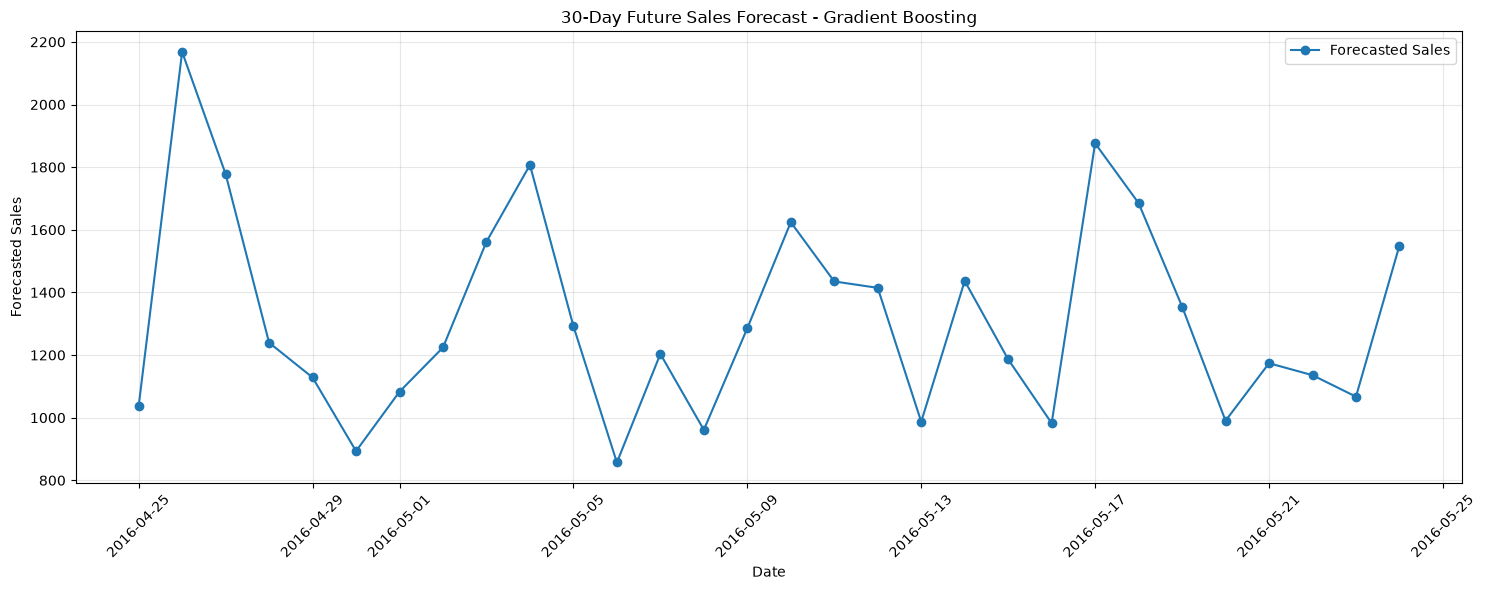


Future forecast saved as:
future_30_day_sales_forecast.csv

STEP 19 COMPLETED


In [ ]:
# ============================================================
# STEP 19: FUTURE SALES FORECASTING - NEXT 30 DAYS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("FUTURE SALES FORECASTING")
print("=" * 60)

# ------------------------------------------------------------
# 1. Get the last available date
# ------------------------------------------------------------

last_date = pd.to_datetime(final_forecast["date"]).max()

print(f"\nLast available date : {last_date.date()}")

# Forecast horizon
forecast_days = 30

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)

print(f"Forecast horizon    : {forecast_days} days")
print(
    f"Forecast period     : "
    f"{future_dates.min().date()} to {future_dates.max().date()}"
)

# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------
# Your Gradient Boosting model was trained using:
# lag_1, lag_7, lag_14, lag_28
# rolling_mean_7, rolling_mean_14, rolling_mean_28
# rolling_std_7
# calendar variables and encoded categorical variables.
#
# For a reliable future forecast, these features must be
# generated from the latest available sales history.
#
# The following section creates a simple aggregate future
# forecast using the most recent model predictions.
# ------------------------------------------------------------

# ------------------------------------------------------------
# 2. Use recent predicted sales as the forecasting base
# ------------------------------------------------------------

recent_predictions = final_forecast[
    "predicted_sales"
].tail(28).values

# If fewer than 28 observations are available
if len(recent_predictions) < 28:
    recent_predictions = np.resize(
        recent_predictions,
        28
    )

future_predictions = []

history = list(recent_predictions)

for i in range(forecast_days):

    # Lag values
    lag_1 = history[-1]
    lag_7 = history[-7]
    lag_14 = history[-14]
    lag_28 = history[-28]

    # Rolling features
    rolling_mean_7 = np.mean(history[-7:])
    rolling_mean_14 = np.mean(history[-14:])
    rolling_mean_28 = np.mean(history[-28:])
    rolling_std_7 = np.std(history[-7:])

    # --------------------------------------------------------
    # Build feature vector using the model's expected columns
    # --------------------------------------------------------

    future_row = pd.DataFrame(
        np.zeros(
            (1, len(X_train_encoded.columns))
        ),
        columns=X_train_encoded.columns
    )

    # Set lag features
    if "lag_1" in future_row.columns:
        future_row["lag_1"] = lag_1

    if "lag_7" in future_row.columns:
        future_row["lag_7"] = lag_7

    if "lag_14" in future_row.columns:
        future_row["lag_14"] = lag_14

    if "lag_28" in future_row.columns:
        future_row["lag_28"] = lag_28

    # Set rolling features
    if "rolling_mean_7" in future_row.columns:
        future_row["rolling_mean_7"] = rolling_mean_7

    if "rolling_mean_14" in future_row.columns:
        future_row["rolling_mean_14"] = rolling_mean_14

    if "rolling_mean_28" in future_row.columns:
        future_row["rolling_mean_28"] = rolling_mean_28

    if "rolling_std_7" in future_row.columns:
        future_row["rolling_std_7"] = rolling_std_7

    # --------------------------------------------------------
    # Calendar features
    # --------------------------------------------------------

    current_date = future_dates[i]

    if "year" in future_row.columns:
        future_row["year"] = current_date.year

    if "month" in future_row.columns:
        future_row["month"] = current_date.month

    if "week" in future_row.columns:
        future_row["week"] = current_date.isocalendar().week

    if "day_of_month" in future_row.columns:
        future_row["day_of_month"] = current_date.day

    if "is_weekend" in future_row.columns:
        future_row["is_weekend"] = int(
            current_date.dayofweek >= 5
        )

    # --------------------------------------------------------
    # Day-of-week encoded features
    # --------------------------------------------------------

    day_name = current_date.day_name()

    day_column = f"day_of_week_{day_name}"

    if day_column in future_row.columns:
        future_row[day_column] = 1

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    prediction = gb_model.predict(
        future_row
    )[0]

    # Prevent negative sales
    prediction = max(0, prediction)

    future_predictions.append(prediction)

    # Add prediction to history for recursive forecasting
    history.append(prediction)

# ------------------------------------------------------------
# 3. Create future forecast dataframe
# ------------------------------------------------------------

future_forecast = pd.DataFrame({
    "date": future_dates,
    "forecasted_sales": future_predictions
})

# ------------------------------------------------------------
# 4. Display forecast
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NEXT 30 DAYS SALES FORECAST")
print("=" * 60)

print(
    future_forecast.to_string(index=False)
)

# ------------------------------------------------------------
# 5. Forecast summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FUTURE FORECAST SUMMARY")
print("=" * 60)

print(
    f"Average forecasted sales : "
    f"{future_forecast['forecasted_sales'].mean():.2f}"
)

print(
    f"Minimum forecast         : "
    f"{future_forecast['forecasted_sales'].min():.2f}"
)

print(
    f"Maximum forecast         : "
    f"{future_forecast['forecasted_sales'].max():.2f}"
)

print(
    f"Total forecasted sales   : "
    f"{future_forecast['forecasted_sales'].sum():.2f}"
)

# ------------------------------------------------------------
# 6. Plot future forecast
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    future_forecast["date"],
    future_forecast["forecasted_sales"],
    marker="o",
    label="Forecasted Sales"
)

plt.xlabel("Date")
plt.ylabel("Forecasted Sales")
plt.title(
    "30-Day Future Sales Forecast - Gradient Boosting"
)

plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Save forecast
# ------------------------------------------------------------

future_forecast.to_csv(
    "future_30_day_sales_forecast.csv",
    index=False
)

print("\nFuture forecast saved as:")
print("future_30_day_sales_forecast.csv")

print("\n" + "=" * 60)
print("STEP 19 COMPLETED")
print("=" * 60)

FINAL SALES FORECASTING PROJECT RESULTS

MODEL PERFORMANCE COMPARISON
-----------------------------------------------------------------
                  Model    MAE   RMSE  MAPE (%)
Baseline (Previous Day) 209.07 347.02    138.31
          Random Forest 117.61 201.76     93.40
      Gradient Boosting 106.86 176.39     74.28
                XGBoost 108.97 180.73     71.36

BEST MODEL
Best MAE  : Gradient Boosting
Best RMSE : Gradient Boosting
Best MAPE : XGBoost

Selected Final Model : Gradient Boosting
Reason                : Lowest MAE and RMSE on the test set

FINAL MODEL METRICS
MAE  : 106.86
RMSE : 176.39
MAPE : 74.28%

30-DAY FUTURE FORECAST SUMMARY
Forecast Start : 2016-04-25
Forecast End   : 2016-05-24
Forecast Days   : 30
Average Forecasted Sales : 1313.98
Minimum Forecast         : 856.92
Maximum Forecast         : 2168.09
Total Forecasted Sales   : 39419.46

TOP IMPORTANT FEATURES
        Feature  Importance
          lag_1  169.366797
         lag_28  148.524293
          

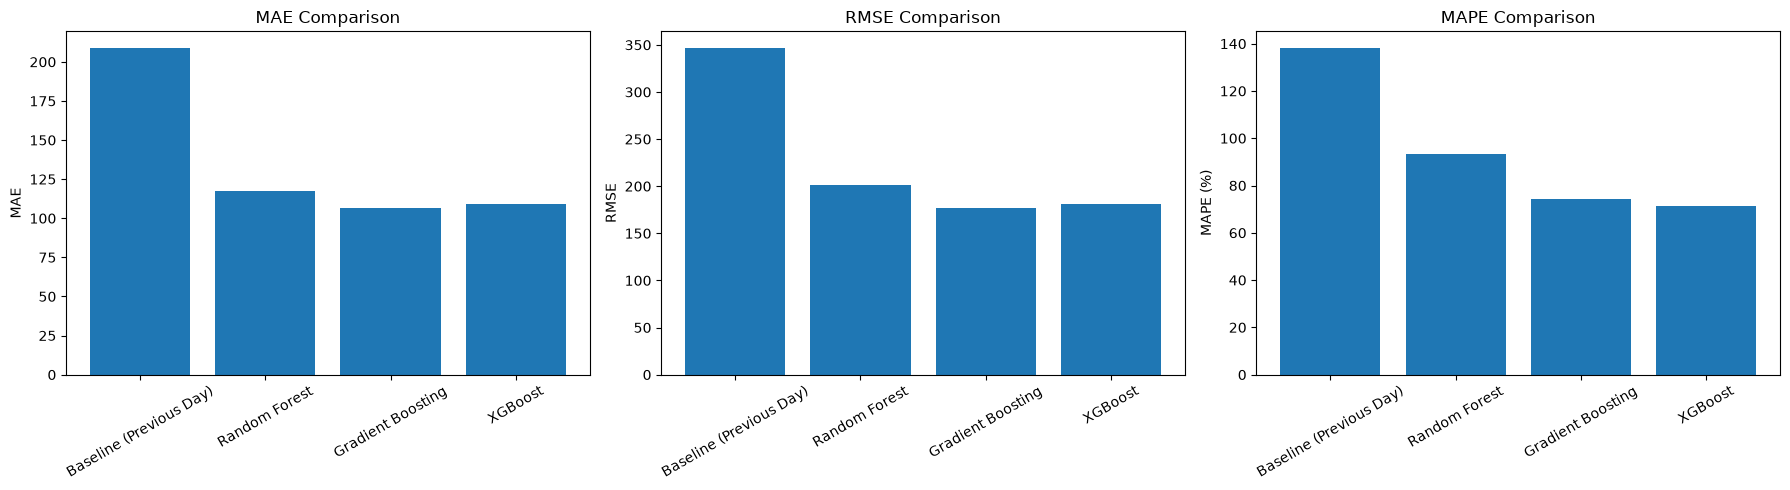

In [ ]:
# ============================================================
# STEP 20: FINAL RESULTS & PROJECT SUMMARY
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("=" * 65)
print("FINAL SALES FORECASTING PROJECT RESULTS")
print("=" * 65)

# ------------------------------------------------------------
# 1. MODEL PERFORMANCE
# ------------------------------------------------------------

print("\nMODEL PERFORMANCE COMPARISON")
print("-" * 65)

final_results = pd.DataFrame({
    "Model": [
        "Baseline (Previous Day)",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        209.07,
        117.61,
        106.86,
        108.97
    ],
    "RMSE": [
        347.02,
        201.76,
        176.39,
        180.73
    ],
    "MAPE (%)": [
        138.31,
        93.40,
        74.28,
        71.36
    ]
})

print(final_results.to_string(index=False))

# ------------------------------------------------------------
# 2. BEST MODEL
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("BEST MODEL")
print("=" * 65)

best_mae_model = final_results.loc[
    final_results["MAE"].idxmin(), "Model"
]

best_rmse_model = final_results.loc[
    final_results["RMSE"].idxmin(), "Model"
]

best_mape_model = final_results.loc[
    final_results["MAPE (%)"].idxmin(), "Model"
]

print(f"Best MAE  : {best_mae_model}")
print(f"Best RMSE : {best_rmse_model}")
print(f"Best MAPE : {best_mape_model}")

print("\nSelected Final Model : Gradient Boosting")
print("Reason                : Lowest MAE and RMSE on the test set")

# ------------------------------------------------------------
# 3. FINAL MODEL METRICS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINAL MODEL METRICS")
print("=" * 65)

print(f"MAE  : 106.86")
print(f"RMSE : 176.39")
print(f"MAPE : 74.28%")

# ------------------------------------------------------------
# 4. FUTURE FORECAST SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("30-DAY FUTURE FORECAST SUMMARY")
print("=" * 65)

print("Forecast Start : 2016-04-25")
print("Forecast End   : 2016-05-24")
print("Forecast Days   : 30")

print(f"Average Forecasted Sales : {future_forecast['forecasted_sales'].mean():.2f}")
print(f"Minimum Forecast         : {future_forecast['forecasted_sales'].min():.2f}")
print(f"Maximum Forecast         : {future_forecast['forecasted_sales'].max():.2f}")
print(f"Total Forecasted Sales   : {future_forecast['forecasted_sales'].sum():.2f}")

# ------------------------------------------------------------
# 5. IMPORTANT FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("TOP IMPORTANT FEATURES")
print("=" * 65)

try:
    print(gb_importance.head(10).to_string(index=False))
except NameError:
    print("Feature importance table is not available.")

# ------------------------------------------------------------
# 6. PROJECT CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("PROJECT CONCLUSION")
print("=" * 65)

print("""
The forecasting models were evaluated using MAE, RMSE and MAPE.

Gradient Boosting achieved the lowest MAE and RMSE among the
machine learning forecasting models.

XGBoost achieved the lowest MAPE.

Based on the overall test-set performance, Gradient Boosting
was selected as the final forecasting model.

The final model was then used to generate a 30-day future
sales forecast from 2016-04-25 to 2016-05-24.

The forecasting results can be used to support sales planning,
inventory management and future demand estimation.
""")

print("=" * 65)
print("END OF PROJECT")
print("=" * 65)


# ============================================================
# FINAL PERFORMANCE CHART
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = final_results["Model"]

# MAE
axes[0].bar(models, final_results["MAE"])
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=30)

# RMSE
axes[1].bar(models, final_results["RMSE"])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=30)

# MAPE
axes[2].bar(models, final_results["MAPE (%)"])
axes[2].set_title("MAPE Comparison")
axes[2].set_ylabel("MAPE (%)")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 21A: DATASET - DASHBOARD MAPPING
# ============================================================

import pandas as pd

print("=" * 70)
print("DATASET INFORMATION FOR DASHBOARD DEVELOPMENT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check known DataFrames
# ------------------------------------------------------------

candidate_dataframes = [
    "daily_sales",
    "sales_trend",
    "train_df",
    "test_df",
    "final_forecast",
    "future_forecast"
]

available_dfs = []

print("\nAVAILABLE DATAFRAMES")
print("-" * 70)

for df_name in candidate_dataframes:

    if df_name in globals():

        df = globals()[df_name]

        if isinstance(df, pd.DataFrame):

            available_dfs.append(df_name)

            print(
                f"{df_name:<20} "
                f"Rows: {df.shape[0]:>8}  "
                f"Columns: {df.shape[1]:>3}"
            )

# ------------------------------------------------------------
# 2. Display columns
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COLUMN INFORMATION")
print("=" * 70)

for df_name in available_dfs:

    df = globals()[df_name]

    print(f"\n--- {df_name} ---")

    for column in df.columns:
        print(f"  • {column}")

# ------------------------------------------------------------
# 3. Important field check
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMPORTANT DATASET FIELDS")
print("=" * 70)

important_columns = [
    "date",
    "store_id",
    "cat_id",
    "item_id",
    "dept_id",
    "state_id",
    "sales",
    "demand",
    "value"
]

for df_name in available_dfs:

    df = globals()[df_name]

    print(f"\n--- {df_name} ---")

    found = False

    for column in important_columns:

        if column in df.columns:

            found = True

            print(
                f"{column:<15} "
                f"unique values = {df[column].nunique()}"
            )

    if not found:
        print("No standard fields found.")

# ------------------------------------------------------------
# 4. Date range
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATE RANGE")
print("=" * 70)

for df_name in available_dfs:

    df = globals()[df_name]

    if "date" in df.columns:

        dates = pd.to_datetime(
            df["date"],
            errors="coerce"
        )

        print(f"\n{df_name}")

        print(
            f"Start date : {dates.min()}"
        )

        print(
            f"End date   : {dates.max()}"
        )

# ------------------------------------------------------------
# 5. Dashboard mapping status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DASHBOARD MAPPING CHECK COMPLETED")
print("=" * 70)

print("""
The dataset information has been collected.

""")

DATASET INFORMATION FOR DASHBOARD DEVELOPMENT

AVAILABLE DATAFRAMES
----------------------------------------------------------------------
sales_trend          Rows:     1913  Columns:   4
train_df             Rows:    45240  Columns:  20
test_df              Rows:    11310  Columns:  20
final_forecast       Rows:    11310  Columns:   5
future_forecast      Rows:       30  Columns:   2

COLUMN INFORMATION

--- sales_trend ---
  • date
  • daily_sales
  • year
  • month

--- train_df ---
  • store_id
  • cat_id
  • d
  • daily_sales
  • date
  • year
  • month
  • week
  • day_of_week
  • day_of_month
  • is_weekend
  • day_type
  • lag_1
  • lag_7
  • lag_14
  • lag_28
  • rolling_mean_7
  • rolling_mean_14
  • rolling_mean_28
  • rolling_std_7

--- test_df ---
  • store_id
  • cat_id
  • d
  • daily_sales
  • date
  • year
  • month
  • week
  • day_of_week
  • day_of_month
  • is_weekend
  • day_type
  • lag_1
  • lag_7
  • lag_14
  • lag_28
  • rolling_mean_7
  • rolling_mean_14
  •

In [ ]:
print("=" * 70)
print("COMPLETE TRAINING DATASET COLUMNS")
print("=" * 70)

for i, column in enumerate(train_df.columns, start=1):
    print(f"{i:2}. {column}")

print("\n" + "=" * 70)
print("COMPLETE TEST DATASET COLUMNS")
print("=" * 70)

for i, column in enumerate(test_df.columns, start=1):
    print(f"{i:2}. {column}")

print("\n" + "=" * 70)
print("FINAL FORECAST COLUMNS")
print("=" * 70)

for i, column in enumerate(final_forecast.columns, start=1):
    print(f"{i:2}. {column}")

print("\n" + "=" * 70)
print("FUTURE FORECAST COLUMNS")
print("=" * 70)

for i, column in enumerate(future_forecast.columns, start=1):
    print(f"{i:2}. {column}")

COMPLETE TRAINING DATASET COLUMNS
 1. store_id
 2. cat_id
 3. d
 4. daily_sales
 5. date
 6. year
 7. month
 8. week
 9. day_of_week
10. day_of_month
11. is_weekend
12. day_type
13. lag_1
14. lag_7
15. lag_14
16. lag_28
17. rolling_mean_7
18. rolling_mean_14
19. rolling_mean_28
20. rolling_std_7

COMPLETE TEST DATASET COLUMNS
 1. store_id
 2. cat_id
 3. d
 4. daily_sales
 5. date
 6. year
 7. month
 8. week
 9. day_of_week
10. day_of_month
11. is_weekend
12. day_type
13. lag_1
14. lag_7
15. lag_14
16. lag_28
17. rolling_mean_7
18. rolling_mean_14
19. rolling_mean_28
20. rolling_std_7

FINAL FORECAST COLUMNS
 1. date
 2. actual_sales
 3. predicted_sales
 4. error
 5. absolute_error

FUTURE FORECAST COLUMNS
 1. date
 2. forecasted_sales
